# Refactored CellWhisperer Analysis Notebook

This script performs post-processing analysis on AnnData objects
previously processed with CellWhisperer, focusing on developmental
time courses, organ emergence, marker gene identification, and comparison
with reference datasets and literature.

**Refactoring Goals:**
- Improve code clarity and organization.
- Remove external API calls for CellWhisperer scoring, relying solely on a local model.
- Reduce code redundancy by using functions.
- Flag potential bugs and areas for improvement.

## 1. Setup and Configuration

In [1]:
#import os
#os.environ["LD_LIBRARY_PATH"]="/msc/home/mschae83/NVIDIA-Linux-x86_64-535.129.03/"

In [2]:
# ### 1.1 Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import patches
import plotly.graph_objects as go
from IPython.core.display import display, HTML
from scipy import stats
from scipy.cluster import hierarchy as sch
from scipy.sparse import issparse # For checking sparse matrix type
import re
import json
import subprocess # Retained for potential non-API uses, but API calls removed
import shlex
import statsmodels.api as sm # Use main API instead of sandbox if possible
from statsmodels.stats.multitest import multipletests # Corrected import path
import scanpy as sc
import anndata
import scipy
from collections import defaultdict, Counter
import os
import time
import datetime
import zipfile
import pickle as pk
from matplotlib_venn import venn2,venn3
import networkx as nx
import warnings
from pathlib import Path # For better path handling
from SPARQLWrapper import SPARQLWrapper, JSON # External Call
from Bio import Entrez # External Call
import gseapy as gp
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
# if module is available, import it
try:
    from statannotations.Annotator import Annotator # For significance annotations
    statsannotations_available = True
except ImportError:
    print("statannotations module not found. Skipping import.")
    statsannotations_available = False

import utils
from utils import * # Custom utility functions

# reimport utils
import importlib
importlib.reload(utils)
from utils import * # Custom utility functions

/tmp/ipykernel_1566824/29152549.py:9: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/scanpy/_metadata.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


statannotations module not found. Skipping import.
statannotations module not found. Skipping import.
statannotations module not found. Skipping import.


In [3]:
matplotlib.style.use("/msc/home/q56ppene/cellwhisperer/cellwhisperer/src/plot_style/main.style")


In [4]:
# CellWhisperer specific imports (assuming installed)
from cellwhisperer.utils.model_io import load_cellwhisperer_model
from cellwhisperer.utils.inference import score_transcriptomes_vs_texts
from cellwhisperer.config import get_path # May need adjustment based on installation
import torch

/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/wandb/analytics/sentry.py:90: SentryHubDeprecationWarning: `sentry_sdk.Hub` is deprecated and will be removed in a future major release. Please consult our 1.x to 2.x migration guide for details on how to migrate `Hub` usage to the new API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x
  self.hub = sentry_sdk.Hub(client)


### 1.2 Configuration & Constants

In [5]:
RERUN_M1_MARKER_FINDING = False #True
RERUN_M2_MARKER_FINDING = False #True #False
RERUN_LITERATURE_SEARCH = False #False
RERUN_CW_PREDICTIONS = False

In [6]:
# Paths
# POTENTIAL ISSUE: Hardcoded input/output paths reduce portability. Use relative paths or configuration files.
BASE_DIR = Path(".") # Assume notebook runs in the project root
INPUT_DIR = BASE_DIR / "input"
OUTPUT_DIR = BASE_DIR / "output"
MODEL_DIR = Path("/msc/home/mschae83/cellwhisperer_private/results/models/jointemb") # Example path
DISEASE_DATA_DIR = INPUT_DIR / "Diseases" / "rgd_neonatal_diseases"
DISEASE_ZIP = INPUT_DIR / "Diseases-20250402T070239Z-001.zip"

In [7]:
#! ADATA_INPUT_PATH = Path("/msc/home/mschae83/cellwhisperer_private/results/development3s/cellwhisperer_clip_v1/cellxgene.h5ad") # Example path
ADATA_INPUT_PATH = INPUT_DIR / "raw_s1tos3_scvi10kgene_s20250216.adata"  # rclone copy --drive-shared-with-me "gdoc_salvo:forMoritz/Moritz_post_revision_0325/s1tos3_scvi10kgene_s20250307.adata" cellwhisperer/cellwhisperer/src/experiments/573-early-dev-fig-5-revision-phase/
# ADATA_INPUT_PATH = INPUT_DIR / "cellxgene.h5ad" # Alternative if local
MARKER_GENE_XLS_PATH = INPUT_DIR / "aba7721_tabless1-s16.xlsx"
PEDIATRIC_CANCER_GENES_PATH = INPUT_DIR / "Diseases" / "Pediatric_cancer_genes.txt"
CW_CHECKPOINT_PATH = MODEL_DIR / "cellwhisperer_clip_v1.ckpt"

In [8]:
# Ensure output directory exists
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
# Parameters
SEED = 25
BACKGROUND_GENE_SET_SIZE = 10000 # Used for Fisher's exact test background
CELL_QUANTILE_THRESHOLD = 0.97 # For selecting top scoring cells
MARKER_LOGFC_THRESHOLD = 1.5 #2 #! was 2.0 # For selecting marker genes (Method 1)
MARKER_FDR_THRESHOLD = 0.05 # For selecting marker genes (Method 1) & Fisher's test significance
MARKER_CORR_THRESHOLD = 0.3 # For selecting marker genes (Method 2)
CUTOFF_DISEASE_ASSOCIATION = 2 
PUBMED_EMAIL = "penederpeter@gmail.com"
PUBMED_API_KEY = "90a10857754ea611a586eec732ae51db8508" # Replace with your actual API key
PUBMED_RATE_LIMIT_DELAY = 0.12 #0.5 # Seconds between Entrez queries to avoid blocking (10/sec allowed with API key)

CORR_METHOD="kendall" # or "pearson"

In [10]:
ORGAN_GERM_LAYER_ASSOC_DICT = {
    'blood': 'mesoderm',
    'cerebrum': 'ectoderm',
    'heart': 'mesoderm',
    'intestine': 'endoderm',
    'kidney': 'mesoderm',
    'large intestine': 'endoderm',
    'liver': 'endoderm',
    'lung': 'endoderm',
    'muscle': 'mesoderm',
    'pancreas': 'endoderm',
    'skin': 'ectoderm',
    'small intestine': 'endoderm',
    'spleen': 'mesoderm',
    'stomach': 'endoderm',
    'vasculature': 'mesoderm'
}
GERM_LAYER_COLORS = {
    "mesoderm": "#E63946",  # A vibrant crimson red
    "ectoderm": "#457B9D",  # A muted teal blue
    "endoderm": "#F9C74F"   # A warm amber/gold
}
ORGAN_COLOR_DICT={organ:GERM_LAYER_COLORS[germlayer] for organ, germlayer in ORGAN_GERM_LAYER_ASSOC_DICT.items()}

In [11]:
# Gene Sets & Ontologies
ORGANS_TABSAP = [
    "Liver", "Blood", "Spleen", "Skin", "Heart", "Pancreas",
    "Muscle", "Large Intestine", "Lung", "Small Intestine",
    "Vasculature", "Kidney"
] 
ORGANS_TABSAP_LOWER = [x.lower() for x in ORGANS_TABSAP]

In [12]:
ORGANS_BBI = [
    "Cerebrum", "Heart", "Intestine", "Kidney", "Liver", "Lung",
    "Muscle", "Pancreas", "Spleen", "Stomach"
] # Removed commented-out organs
ORGANS_BBI_LOWER = [x.lower() for x in ORGANS_BBI]

In [13]:
# Combine and ensure uniqueness + sorting
ALL_ORGANS = sorted(list(set(ORGANS_TABSAP_LOWER + ORGANS_BBI_LOWER)))

In [14]:
DEVELOPMENT_TERMS_SIMPLE = ["Zygote", "Blastocyst", "Gastrulation", "Organogenesis"]
DEVELOPMENT_TERMS_SIMPLE_LOWER = [t.lower() for t in DEVELOPMENT_TERMS_SIMPLE]

In [15]:
DEVELOPMENT_TERMS_CURATED = [
    "Fertilized egg", "Zygote", "Embryogenesis", "Fetus", "Blastocyst",
    "Gastrulation", "Genome activation", "Organogenesis", "Methylation",
    "Cell lineages", "Multi-lineage differentiation", "Differentiation",
    "Implantation", "Development"
]
DEVELOPMENT_TERMS_CURATED_LOWER = [t.lower() for t in DEVELOPMENT_TERMS_CURATED]

In [16]:
GERM_LAYERS = ["endoderm", "mesoderm", "ectoderm"]

In [17]:
# Lists of terms for CellWhisperer scoring (combine all needed)
ALL_CW_TERMS = sorted(list(set(
    ALL_ORGANS +
    DEVELOPMENT_TERMS_SIMPLE_LOWER +
    DEVELOPMENT_TERMS_CURATED_LOWER +
    GERM_LAYERS +
    ["trophoblast cells"]
    # Add Carnegie terms/descriptions later if fetched successfully
)))

In [18]:
# Enrichment Libraries
ENRICHMENT_LIBRARIES = [
    'GO_Biological_Process_2023',
    'GO_Molecular_Function_2023',
    'GO_Cellular_Component_2023',
    'KEGG_2021_Human'
]

In [19]:
# Plotting Colors
ORGAN_COLORS = {
    "cerebrum": "teal", "heart": "crimson", "intestine": "turquoise",
    "kidney": "darkviolet", "liver": "olive", "lung": "royalblue",
    "muscle": "pink", "pancreas": "coral", "spleen": "navy",
    "stomach": "orange",
    "blood": "red", "skin": "peru", "large intestine": "saddlebrown",
    "small intestine": "burlywood", "vasculature": "firebrick",
    # Add colors for other ORGANS_TABSAP if needed
    "none": "lightgray" # Default/unassigned color
}
# Ensure all ALL_ORGANS have a color, assign gray if missing
for organ in ALL_ORGANS:
    if organ not in ORGAN_COLORS:
        ORGAN_COLORS[organ] = "gray"
        warnings.warn(f"Assigning default gray color to organ: {organ}")

### 1.3 Global Settings & Environment

In [20]:
# Set global seeds
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

In [21]:
# Set plotting style defaults
plt.style.use("default")
sns.set_style("whitegrid")
matplotlib.rcParams['pdf.fonttype'] = 42 # Ensure editable text in PDFs
matplotlib.rcParams['ps.fonttype'] = 42

In [22]:
# Suppress specific warnings if needed (use with caution)
warnings.filterwarnings("ignore", category=UserWarning, message=".*Observation names are not unique.*")
warnings.filterwarnings("ignore", category=FutureWarning) # Example

In [23]:
print(f"Notebook started: {datetime.datetime.now()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Input AnnData: {ADATA_INPUT_PATH.resolve()}")

Notebook started: 2025-06-17 10:30:34.630313
Output directory: /msc/home/q56ppene/cellwhisperer/cellwhisperer/src/experiments/573-early-dev-fig-5-revision-phase/output
Input AnnData: /msc/home/q56ppene/cellwhisperer/cellwhisperer/src/experiments/573-early-dev-fig-5-revision-phase/input/raw_s1tos3_scvi10kgene_s20250216.adata


## 3. Data Loading and Initial Processing

In [24]:
print("\n--- Loading Data ---")
try:
    adata = anndata.read_h5ad(ADATA_INPUT_PATH)
    print(f"Loaded AnnData object: {adata.shape}")
except FileNotFoundError:
    print(f"Error: AnnData file not found at {ADATA_INPUT_PATH}")
    # Exit or raise error if adata is crucial
    raise SystemExit("Input data file missing.")


--- Loading Data ---


Loaded AnnData object: (95092, 10000)


In [25]:
adata

AnnData object with n_obs × n_vars = 95092 × 10000
    obs: 'anno_og', 'age', 'batch', 'instrument', 'institution', 'protocol', 'AvgReadLen', 'country', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'organism_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'tissue_ontology_term_id', 'Clusters', '_X', '_Y', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'anno_og_time', '_scvi_batch', '_scvi_labels'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'anno_og_colors', 'batch_colors', 'scvi', 'umap'
    obsm: 'X_umap', 'scvi'
    la

In [26]:
adata.obs.batch.unique().tolist() # Check batch names

['PRJEB30442',
 'EMTAB3929',
 'EMTAB8060_B1',
 'EMTAB8060_B2',
 'PRJEB40781',
 'GSE155121',
 'GSE232861']

In [27]:
# --- Basic AnnData Checks ---
# if 'transcriptome_embeds' not in adata.obsm:
#      raise ValueError("Missing 'transcriptome_embeds' in adata.obsm. Cannot run CellWhisperer scoring.")
if not adata.var.index.name or adata.var.index.name.lower() != 'accession':
    if 'Accession' in adata.var.columns:
        print("Setting adata.var.index to 'Accession' column.")
        adata.var = adata.var.set_index('Accession')
        # POTENTIAL ISSUE: Ensure the 'Accession' column truly contains unique gene identifiers (like Ensembl IDs) expected by the model/downstream steps.
    else:
        # POTENTIAL ISSUE: If 'Accession' column is missing or var index is not set correctly,
        # downstream gene-based operations might fail or use the wrong identifiers.
        warnings.warn("adata.var.index is not named 'Accession'. Ensure index contains correct gene identifiers.")

Setting adata.var.index to 'Accession' column.


/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/anndata/_core/anndata.py:850: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['LINC00115', 'HES4', 'RNF223', 'TNFRSF18', 'ACAP3']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


In [28]:
print("Variable names (genes) example:", adata.var_names[:5].tolist())
print("Observation columns example:", adata.obs.columns[:10].tolist())

Variable names (genes) example: ['LINC00115', 'HES4', 'RNF223', 'TNFRSF18', 'ACAP3']
Observation columns example: ['anno_og', 'age', 'batch', 'instrument', 'institution', 'protocol', 'AvgReadLen', 'country', 'assay_ontology_term_id', 'cell_type_ontology_term_id']


In [29]:
# --- Load Marker Genes ---
try:
    marker_genes_df = pd.read_excel(MARKER_GENE_XLS_PATH, sheet_name='Table_S3', skiprows=1)
    expanded_marker_genes_df = pd.read_excel(MARKER_GENE_XLS_PATH, sheet_name='Table S2', skiprows=1)
    print("Loaded BBI marker gene tables.")
except FileNotFoundError:
    print(f"Error: Marker gene file not found at {MARKER_GENE_XLS_PATH}")
    # Decide how to proceed: exit, use empty markers, etc.
    marker_genes_df = pd.DataFrame() # Example: proceed with empty markers
    expanded_marker_genes_df = pd.DataFrame()
    warnings.warn("Could not load BBI marker genes. Analyses relying on them will be skipped or may fail.")

Loaded BBI marker gene tables.


In [30]:
# --- Time Annotation Processing ---
print("\n--- Processing Time Annotations ---")
if 'anno_og_time' in adata.obs.columns and 'age' in adata.obs.columns:
    unannotated_ages = set(adata.obs.loc[adata.obs['anno_og_time'] == 'unannotated', 'age'])
    print(f"Ages found for 'unannotated' time points: {unannotated_ages}")

    # BUG: The original loop iterates using `iterrows`, which is inefficient.
    # Using vectorized operations is preferred.
    day_map = {'3wpc': 'd18', '4wpc': 'd25'} # Add other mappings if needed
    # Create the new column, initially copying the original time
    adata.obs['anno_og_time_days'] = adata.obs['anno_og_time'].astype(str)
    # Find rows where time is 'unannotated'
    unannotated_mask = adata.obs['anno_og_time_days'] == 'unannotated'
    # Map the 'age' to the corresponding day for these rows
    adata.obs.loc[unannotated_mask, 'anno_og_time_days'] = adata.obs.loc[unannotated_mask, 'age'].map(day_map)

    # Check if any 'unannotated' remain (e.g., due to missing ages in day_map)
    remaining_unannotated = adata.obs.loc[adata.obs['anno_og_time_days'] == 'unannotated'].shape[0]
    if remaining_unannotated > 0:
        warnings.warn(f"{remaining_unannotated} cells still have 'unannotated' time after mapping. Check 'age' values and 'day_map'.")
    else:
         print("Successfully mapped 'unannotated' time points to days.")

    # --- Sort time points naturally (d1, d2, ... d10, d11...) ---
    try:
        # Extract numeric part, handle non-numeric gracefully
        day_numbers = adata.obs['anno_og_time_days'].str.extract(r'd(\d+)', expand=False).astype(float)
        unique_sorted_days = sorted(adata.obs['anno_og_time_days'].unique(),
                                    key=lambda d: float(re.search(r'd(\d+)', d).group(1)) if re.search(r'd(\d+)', d) else float('inf'))
        adata.obs['anno_og_time_days'] = pd.Categorical(adata.obs['anno_og_time_days'], categories=unique_sorted_days, ordered=True)
        print("Time points sorted:", unique_sorted_days)
    except Exception as e:
        warnings.warn(f"Could not sort time points naturally: {e}. Using alphabetical sort.")
        unique_sorted_days = sorted(adata.obs['anno_og_time_days'].unique())
else:
    warnings.warn("Columns 'anno_og_time' or 'age' not found. Cannot create 'anno_og_time_days'.")
    # Handle downstream dependencies if 'anno_og_time_days' is crucial


--- Processing Time Annotations ---
Ages found for 'unannotated' time points: {'3wpc', '4wpc'}
Successfully mapped 'unannotated' time points to days.
Time points sorted: ['d03', 'd04', 'd05', 'd06', 'd07', 'd09', 'd11', 'd12', 'd14', 'd15', 'd16', 'd17', 'd18', 'd19', 'd20', 'd21', 'd25', 'd30', 'd32', 'd35', 'd39']


In [31]:
# --- Calculate Proportion of Extraembryonic Tissue ---
if 'anno_og' in adata.obs.columns:
    extraembryonic_tissues = ['Allantois', 'ExE Endoderm', 'ExE Mesoderm']
    extraembryonic_mask = adata.obs['anno_og'].isin(extraembryonic_tissues)
    n_extraembryonic = extraembryonic_mask.sum()
    prop_extraembryonic = n_extraembryonic / adata.shape[0]
    print(f"Proportion of extraembryonic cells ({', '.join(extraembryonic_tissues)}): {prop_extraembryonic:.2%}")
else:
    print("Warning: 'anno_og' column not found. Cannot calculate proportion of extraembryonic tissue.")

Proportion of extraembryonic cells (Allantois, ExE Endoderm, ExE Mesoderm): 1.01%


/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


## 4. CellWhisperer Scoring (Local Model)

In [32]:
print("\n--- Running CellWhisperer Scoring (Local Model) ---")


--- Running CellWhisperer Scoring (Local Model) ---


In [33]:
# --- Prepare list of ALL terms needed ---
# Fetch Carnegie descriptions if SPARQL worked, otherwise use predefined summaries
ontology_data = fetch_hsapdv_ontology_sparql() # POTENTIAL ISSUE: External call

Attempting to fetch HsapDv ontology via SPARQL...
Error fetching ontology via SPARQL: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1017)>
Proceeding without ontology data.


In [34]:
carnegie_descriptions = {}
if ontology_data:
     # Filter for Carnegie stages and update specific descriptions
    carnegie_stage_pattern = re.compile(r'Carnegie stage \d{2}[abc]?')
    for term, desc in ontology_data.items():
        if carnegie_stage_pattern.match(term):
             carnegie_descriptions[term] = desc
    # Updates (as in original code)
    carnegie_updates = {
        'Carnegie stage 05a': 'Blastula stage during which implantation occurs defined by a solid trophoblast.',
        'Carnegie stage 05b': 'Blastula stage during which implantation occurs defined by a trophoblastic lacunae.',
        'Carnegie stage 05c': 'Blastula stage during which implantation occurs defined by a lacunar vascular circle.',
        'Carnegie stage 06a': 'Gastrula stage during which chorionic villi appear.',
        'Carnegie stage 06b': 'Gastrula stage during which the primitive streak appears.'
    }
    carnegie_descriptions.update(carnegie_updates)
    print(f"Using {len(carnegie_descriptions)} fetched/updated Carnegie stage descriptions.")
    # Add these descriptions to the list of terms to score
    ALL_CW_TERMS.extend([d.lower() for d in carnegie_descriptions.values()])
else:
    print("Warning: Fetch failed")

carnegie_grouped_descriptions = {
    'Zygote_Carnegie_Derived': "The embryonic stage begins with a fertilized oocyte containing pronuclei. It progresses with cell division, reducing cytoplasmic volume and forming inner and outer cell masses.",
    'Blastula_Carnegie_Derived': "The blastula stage begins with the loss of the zona pellucida, forming a free blastocyst. It progresses as the blastocyst attaches and implants into the uterine lining.",
    'Gastrula_Carnegie_Derived': "During the gastrula stage, the extraembryonic mesoderm and primitive streak form. In the neurula stage, gastrulation continues with the appearance of the notochordal process, primitive pit, and notochordal canal.",
    'Organogenesis_Carnegie_Derived': "During organogenesis, somites progressively form, neural folds fuse, and the rostral and caudal neuropores close. As development continues, limb buds, sensory structures, and facial features emerge, followed by ossification, trunk straightening, and the rounding of the head, body, and limbs."
}
ALL_CW_TERMS.extend([d.lower() for d in carnegie_grouped_descriptions.values()])
CARNEGIE_GROUPED_TERMS= list(carnegie_grouped_descriptions.values())
#carnegie_descriptions = carnegie_grouped_descriptions # Use grouped desc for later mapping

In [35]:
# Ensure unique terms
ALL_CW_TERMS = sorted(list(set(ALL_CW_TERMS)))
print(f"Total unique terms/descriptions for CellWhisperer scoring: {len(ALL_CW_TERMS)}")

Total unique terms/descriptions for CellWhisperer scoring: 37


In [36]:
if RERUN_CW_PREDICTIONS:

    # --- Load Local Model ---
    try:
        print(f"Loading CellWhisperer model from: {CW_CHECKPOINT_PATH}")
        pl_model_cellwhisperer, text_processor_cellwhisperer, transcriptome_processor_cellwhisperer = load_cellwhisperer_model(
            model_path=str(CW_CHECKPOINT_PATH), # Ensure path is string
            eval=True
        )
        # Determine device
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        pl_model_cellwhisperer.to(device)
        print(f"Model loaded successfully onto {device}.")

        # --- Score Transcriptomes vs All Terms ---
        # POTENTIAL ISSUE: Ensure adata.obsm["transcriptome_embeds"] exists and is compatible.
        # May require significant memory depending on n_cells and n_terms.
        if "transcriptome_embeds" in adata.obsm.keys():
            transcriptome_embeds_tensor = torch.tensor(
                adata.obsm["transcriptome_embeds"].A if issparse(adata.obsm["transcriptome_embeds"]) else adata.obsm["transcriptome_embeds"],
                device=device
            )
            transcriptome_input=transcriptome_embeds_tensor
        else:
            transcriptome_input=adata

        print(f"Scoring {adata.shape[0]} cells against {len(ALL_CW_TERMS)} terms...")
        scores_tensor, _ = score_transcriptomes_vs_texts(
            model=pl_model_cellwhisperer.model,
            logit_scale=pl_model_cellwhisperer.model.discriminator.temperature.exp(),
            transcriptome_input=transcriptome_input,
            text_list_or_text_embeds=ALL_CW_TERMS,
            average_mode=None, # Get scores per cell
            grouping_keys=None,
            transcriptome_processor=transcriptome_processor_cellwhisperer, # Pass processor if needed by model version
            batch_size=64, # Adjust batch size based on GPU memory
            score_norm_method=None, # Or 'tensor', 'global_norm' etc. if needed
        )
        scores_np = scores_tensor.T.cpu().numpy() # n_cells * n_text
        print("Scoring complete.")

        # Add scores to adata.obs
        for i, term in enumerate(ALL_CW_TERMS):
            # Sanitize term to be a valid column name if necessary (e.g., replace spaces)
            col_name = f"cw_score_{term.replace(' ', '_').replace('.', '').replace(',', '').lower()}"
            adata.obs[col_name] = scores_np[:, i]

        print(f"Added {len(ALL_CW_TERMS)} CellWhisperer scores to adata.obs")

        # --- Create reverse mapping for Carnegie terms ---
        # Map descriptions back to Carnegie stage names for easier access later
        carnegie_desc_to_stage = {v.lower(): k for k, v in carnegie_descriptions.items()}
        for desc_lower, stage_name in carnegie_desc_to_stage.items():
            score_col_name = f"cw_score_{desc_lower.replace(' ', '_').replace('.', '').replace(',', '').lower()}"
            if score_col_name in adata.obs.columns:
                adata.obs[f"cw_score_{stage_name.replace(' ', '_')}"] = adata.obs[score_col_name]
    except FileNotFoundError:
        print(f"Error: CellWhisperer model checkpoint not found at {CW_CHECKPOINT_PATH}")
        raise SystemExit("CellWhisperer model missing.")
    except Exception as e:
        print(f"An error occurred during CellWhisperer scoring: {e}")
        raise SystemExit("CellWhisperer scoring failed.")
    
    #save adata.obs
    adata.obs.to_csv(OUTPUT_DIR/"adata.obs.csv")
else:
    adata.obs=pd.read_csv(OUTPUT_DIR/"adata.obs.csv",index_col=0)

In [37]:
adata.obs.columns.tolist()

['anno_og',
 'age',
 'batch',
 'instrument',
 'institution',
 'protocol',
 'AvgReadLen',
 'country',
 'assay_ontology_term_id',
 'cell_type_ontology_term_id',
 'development_stage_ontology_term_id',
 'disease_ontology_term_id',
 'donor_id',
 'is_primary_data',
 'organism_ontology_term_id',
 'self_reported_ethnicity_ontology_term_id',
 'sex_ontology_term_id',
 'suspension_type',
 'tissue_type',
 'tissue_ontology_term_id',
 'Clusters',
 '_X',
 '_Y',
 'n_genes',
 'n_genes_by_counts',
 'total_counts',
 'total_counts_mt',
 'pct_counts_mt',
 'anno_og_time',
 '_scvi_batch',
 '_scvi_labels',
 'anno_og_time_days',
 'cw_score_blastocyst',
 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_lacunar_vascular_circle',
 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_solid_trophoblast',
 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_trophoblastic_lacunae',
 'cw_score_blastula_stage_during_which_implantation_occurs',
 'cw_score_blastu

In [38]:
adata_old= adata.copy()

#adata=adata[~adata.obs.anno_og_time_days.isin(["d09","d11","d12"])]


#adata=adata[(~adata.obs['anno_og_time_days'].isin(["d9","d11","d12"])) | (adata.obs["cw_score_trophoblast_cells"]<5)]
#adata.obs["cluster_label"]

#adata=adata[~adata.obs['cluster_label'].str.lower.contains("trophoblast")]


/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [39]:
# for organ in ALL_ORGANS:
#     organ=organ.replace(" ","_")
#     adata.obs[f"cw_score_{organ}"]=adata.obs[f"cw_score_{organ}"] - adata.obs[f"cw_score_trophoblast_cells"]

In [40]:
adata

AnnData object with n_obs × n_vars = 95092 × 10000
    obs: 'anno_og', 'age', 'batch', 'instrument', 'institution', 'protocol', 'AvgReadLen', 'country', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'organism_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'tissue_ontology_term_id', 'Clusters', '_X', '_Y', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'anno_og_time', '_scvi_batch', '_scvi_labels', 'anno_og_time_days', 'cw_score_blastocyst', 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_lacunar_vascular_circle', 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_solid_trophoblast', 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_trophoblastic_lacunae', 'cw_score_blastula_stage_during_which_implantation_occ

## 5. Marker Gene Scoring (BBI Reference)

In [41]:
print("\n--- Calculating BBI Reference Marker Gene Scores ---")
# Check if marker gene dataframes were loaded successfully
if marker_genes_df.empty or expanded_marker_genes_df.empty:
    warnings.warn("Skipping BBI marker gene scoring because marker dataframes are empty.")
    organ_marker_genes_dict = {}
    organ_extended_marker_genes_dict = {}
else:
    # --- Prepare BBI Marker Gene Sets ---
    # POTENTIAL ISSUE: Assumes adata.var_names contains gene symbols matching the Excel file.
    # Might need preprocessing/mapping if identifiers differ (e.g., Ensembl vs Symbol).
    available_genes = set(adata.var_names)
    print(f"{len(available_genes)} genes available in AnnData for scoring.")

    organ_marker_genes_dict = defaultdict(set)
    organ_extended_marker_genes_dict = defaultdict(set)

    for organ_bbi in ORGANS_BBI_LOWER:
        # Regular markers
        markers_for_organ = set()
        # Find rows matching the organ (case-insensitive)
        organ_rows = marker_genes_df[marker_genes_df['Organ'].str.lower() == organ_bbi]
        for _, row in organ_rows.iterrows():
            gene_string = row['Gene markers supporting annotation']
            if pd.notna(gene_string):
                # Split, strip whitespace, and filter by available genes
                genes = {g.strip() for g in gene_string.split(',') if g.strip() in available_genes}
                markers_for_organ.update(genes)
        organ_marker_genes_dict[organ_bbi] = markers_for_organ

        # Extended markers (start with regular markers)
        extended_markers_for_organ = set(markers_for_organ) # Start with the base set
        # Filter expanded table for the organ (handle 'Brain' mapping to 'cerebrum')
        # POTENTIAL ISSUE: Ensure qval column exists and is numeric. Handle potential errors.
        try:
            expanded_marker_genes_df['qval'] = pd.to_numeric(expanded_marker_genes_df['qval'], errors='coerce')
            relevant_expanded_rows = expanded_marker_genes_df[
                (expanded_marker_genes_df['qval'] < 0.05) &
                (
                    (expanded_marker_genes_df['max_organ'].str.lower() == organ_bbi) |
                    ((organ_bbi == 'cerebrum') & (expanded_marker_genes_df['max_organ'] == 'Brain'))
                )
            ]
            # Add genes from relevant rows, stripping quotes and checking availability
            for _, row in relevant_expanded_rows.iterrows():
                gene = str(row['gene_short_name']).replace("'", "").strip()
                if gene in available_genes:
                    extended_markers_for_organ.add(gene)
            organ_extended_marker_genes_dict[organ_bbi] = extended_markers_for_organ

        except KeyError as e:
             warnings.warn(f"Column missing in expanded marker gene table: {e}. Extended markers might be incomplete.")
        except Exception as e:
             warnings.warn(f"Error processing expanded marker genes for {organ_bbi}: {e}")


    # --- Calculate Scores using scanpy.tl.score_genes ---
    # POTENTIAL ISSUE: scanpy.tl.score_genes can be sensitive to dataset normalization and gene list size.
    # The scores are relative within the dataset.
    for organ in ORGANS_BBI_LOWER:
        for name, gene_dict in [("regular", organ_marker_genes_dict), ("extended", organ_extended_marker_genes_dict)]:
            gene_list = list(gene_dict[organ])
            score_name = f"score_{organ}_{name}"
            if gene_list: # Only score if gene list is not empty
                sc.tl.score_genes(adata, gene_list=gene_list, score_name=score_name, use_raw=False)
                # Check if score column was actually added before printing
                if score_name in adata.obs.columns:
                     print(f"Calculated {score_name} using {len(gene_list)} genes.")
                else:
                     warnings.warn(f"Failed to calculate {score_name}. Check gene list and data.")
            else:
                print(f"Skipping {score_name}: No marker genes found/available for {organ}.")
                # Add an empty column to avoid KeyErrors later if expected
                adata.obs[score_name] = 0.0 # Or np.nan

/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])



--- Calculating BBI Reference Marker Gene Scores ---
10000 genes available in AnnData for scoring.


Calculated score_cerebrum_regular using 15 genes.
Calculated score_cerebrum_extended using 399 genes.
Calculated score_heart_regular using 51 genes.
Calculated score_heart_extended using 499 genes.
Calculated score_intestine_regular using 39 genes.
Calculated score_intestine_extended using 545 genes.
Calculated score_kidney_regular using 39 genes.
Calculated score_kidney_extended using 319 genes.
Calculated score_liver_regular using 40 genes.
Calculated score_liver_extended using 556 genes.
Calculated score_lung_regular using 47 genes.
Calculated score_lung_extended using 329 genes.
Calculated score_muscle_regular using 36 genes.
Calculated score_muscle_extended using 420 genes.
Calculated score_pancreas_regular using 44 genes.
Calculated score_pancreas_extended using 293 genes.
Calculated score_spleen_regular using 33 genes.
Calculated score_spleen_extended using 524 genes.
Calculated score_stomach_regular using 48 genes.
Calculated score_stomach_extended using 658 genes.


In [42]:
# Save reference markers used (for reproducibility)
if organ_extended_marker_genes_dict:
    pk_path_ref = OUTPUT_DIR / 'reference_BBI_extended_marker_genes.pickle'
    with open(pk_path_ref, 'wb') as handle:
        pk.dump(organ_extended_marker_genes_dict, handle, protocol=pk.HIGHEST_PROTOCOL)
    print(f"Saved reference (BBI Extended) marker genes used for validation to: {pk_path_ref}")

Saved reference (BBI Extended) marker genes used for validation to: output/reference_BBI_extended_marker_genes.pickle


In [43]:
terms_cols_carnegie_grouped = [f"cw_score_{term.replace(' ', '_').replace('.', '').replace(',', '').lower()}" for term in CARNEGIE_GROUPED_TERMS if f"cw_score_{term.replace(' ', '_').replace('.', '').lower()}" in adata.obs.columns]

In [44]:
terms_cols_carnegie_grouped

[]

In [45]:
[f"cw_score_{term.replace(' ', '_').replace('.', '').replace(',', '').lower()}" for term in CARNEGIE_GROUPED_TERMS if f"cw_score_{term.replace(' ', '_').replace('.', '').lower()}" in adata.obs.columns]

[]

## 6. Developmental Stage Analysis

In [46]:

def plot_mean_score_heatmap(df, title, filename, outdir,
                           cmap="RdBu_r", vmin=None, vmax=None,
                           row_cluster=False, col_cluster=False,
                           xlabel="Time Point", ylabel="Term",
                           cbar_title="Mean Score", figsize=(8, 3),
                           normalize=None):
    """Plots a clustered heatmap of mean scores."""
    data_to_plot = df.copy()

    if normalize == 'row':
        # Row-wise Z-score normalization (rows=terms)
        scaler = StandardScaler()
        data_to_plot = pd.DataFrame(scaler.fit_transform(data_to_plot),
                                    index=data_to_plot.index, columns=data_to_plot.columns)
        if vmin is None: vmin = -2
        if vmax is None: vmax = 2
        cbar_title = "Row Z-Score\n" + cbar_title
    if normalize == 'col':
        # Row-wise Z-score normalization (rows=terms)
        scaler = StandardScaler()
        data_to_plot = pd.DataFrame(scaler.fit_transform(data_to_plot.T).T,
                                    index=data_to_plot.index, columns=data_to_plot.columns)
        if vmin is None: vmin = -2
        if vmax is None: vmax = 2
        cbar_title = "Col Z-Score\n" + cbar_title
    elif normalize == 'zscore':
        # Z-score based on global mean/std per term (calculated elsewhere)
        # Assumes input df already contains z-scores
        if vmin is None: vmin = -4
        if vmax is None: vmax = 4
        cbar_title = "Z-Score\n" + cbar_title
    else: # Absolute scores
        if vmin is None:
             vmin = data_to_plot.min().min()
        if vmax is None:
             vmax = data_to_plot.max().max()
        abs_max = max(abs(vmin), abs(vmax))
        vmin = -abs_max
        vmax = abs_max

    g = sns.clustermap(data_to_plot.T, cmap=cmap, vmin=vmin, vmax=vmax,
                       row_cluster=row_cluster, col_cluster=col_cluster,
                       figsize=figsize, cbar_pos=(0.02, .3, .03, .4), # Adjust cbar position
                       linewidths=0.5, linecolor='gray') # Add subtle lines

    g.ax_heatmap.set_xlabel(xlabel)
    g.ax_heatmap.set_ylabel(ylabel)
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=0)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
    g.cax.set_title(cbar_title, rotation=0, ha='left', va='center', fontsize=10) # Adjust cbar title
    g.ax_heatmap.grid(False) # Turn off grid lines on heatmap
    plt.suptitle(title, y=1.02) # Add main title above heatmap

    #rotate the x ticks
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
    filepath = outdir / filename
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Saved heatmap to: {filepath}")
    plt.show()
    plt.close() # Close figure to free memory


--- Analyzing Developmental Stage Scores ---
Saved heatmap to: output/dev_terms_simple_heatmap_absolute.pdf


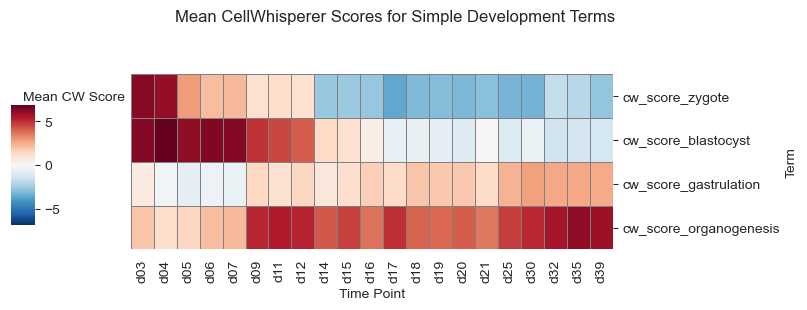

Saved heatmap to: output/dev_terms_simple_heatmap_row_norm.pdf


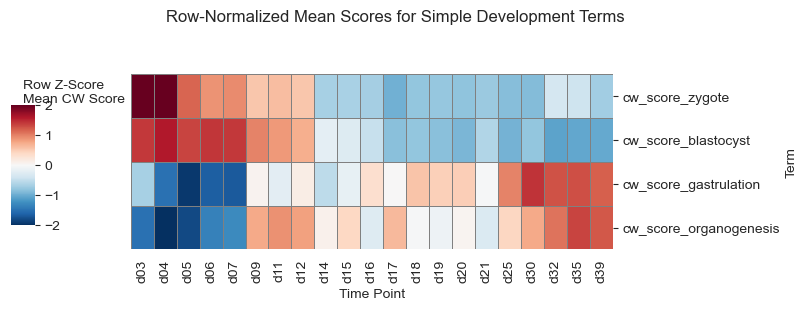

/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


Saved heatmap to: output/dev_terms_carnegie_grouped_heatmap_absolute.pdf


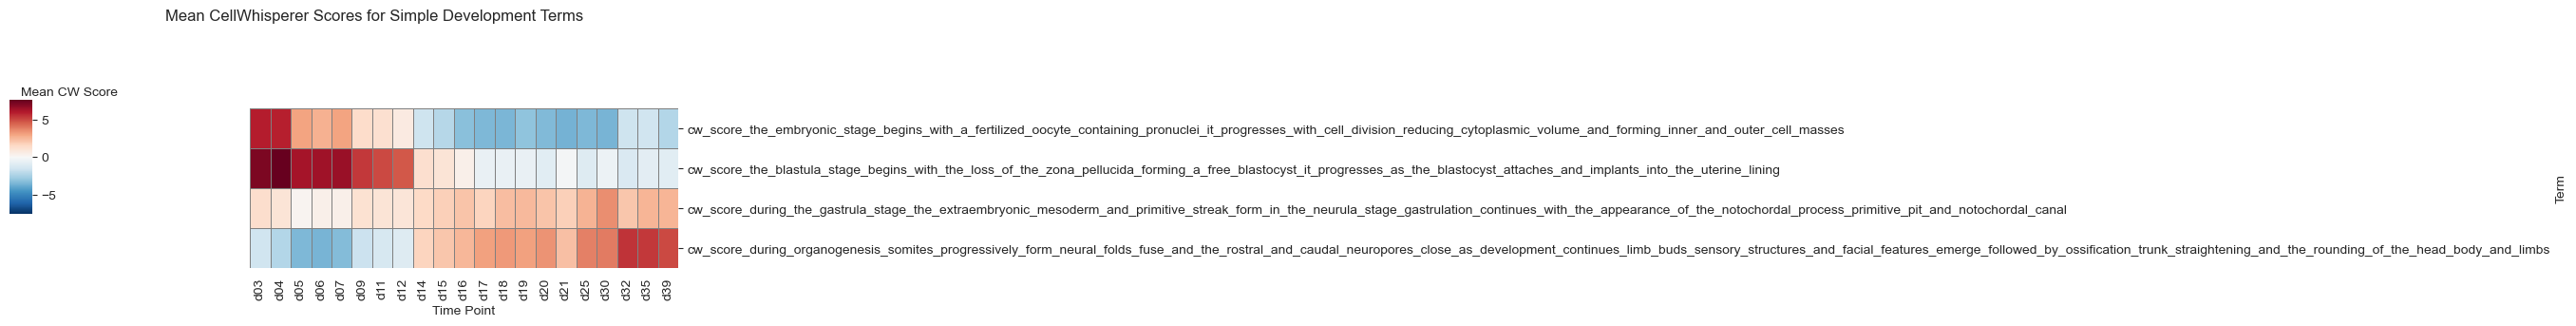

/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


Saved heatmap to: output/dev_terms_carnegie_grouped_heatmap_row_norm.pdf


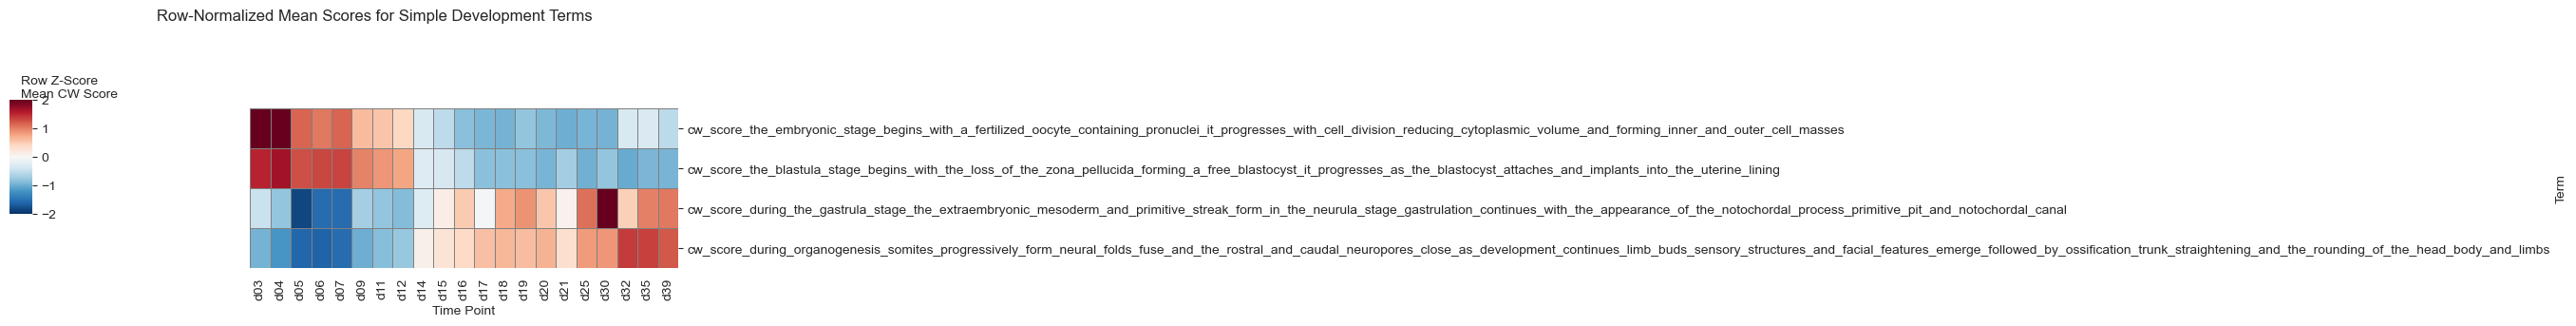

/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


Saved heatmap to: output/dev_terms_carnegie_grouped_heatmap_col_norm.pdf


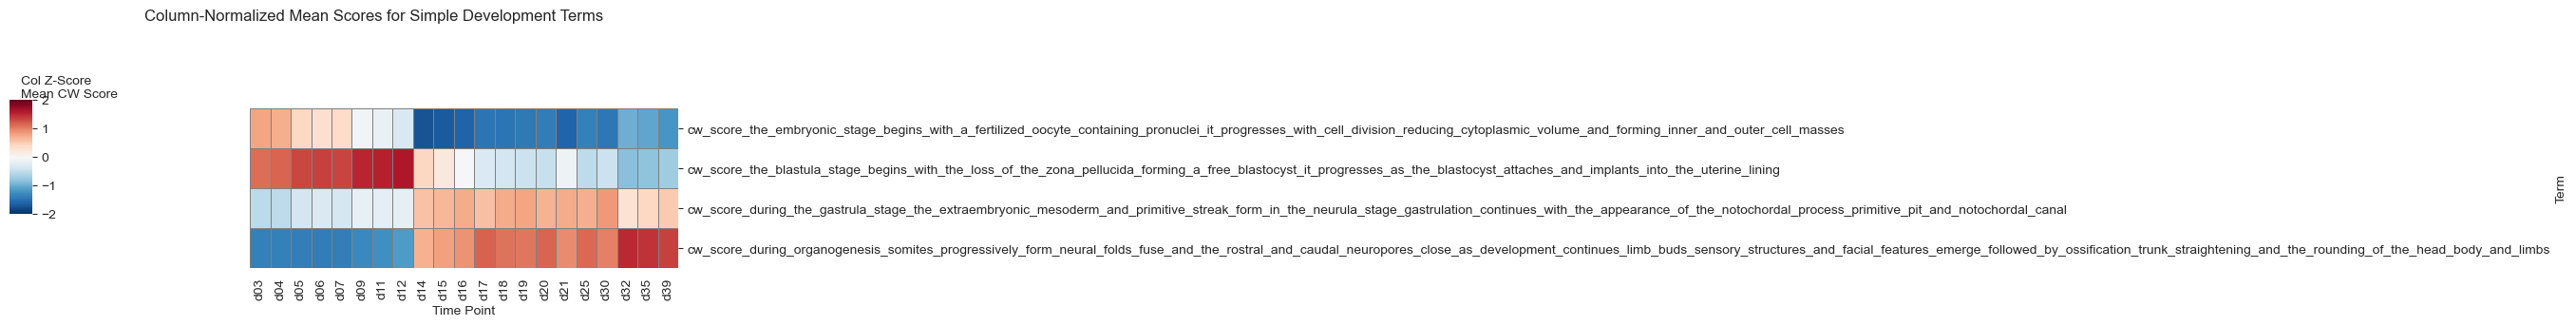

Saved heatmap to: output/dev_terms_curated_heatmap_absolute.pdf


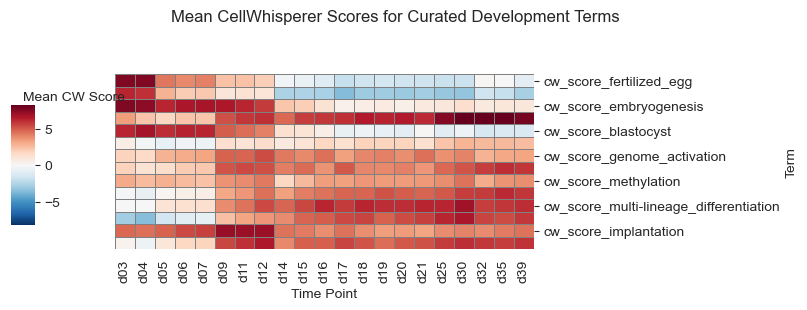

Saved heatmap to: output/dev_terms_curated_heatmap_row_norm.pdf


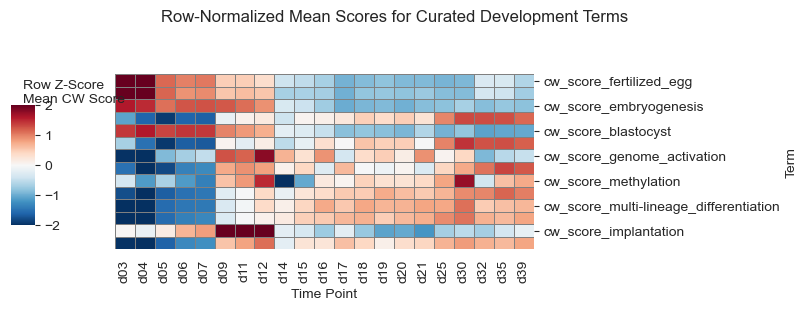

Saved heatmap to: output/dev_terms_curated_heatmap_col_norm.pdf


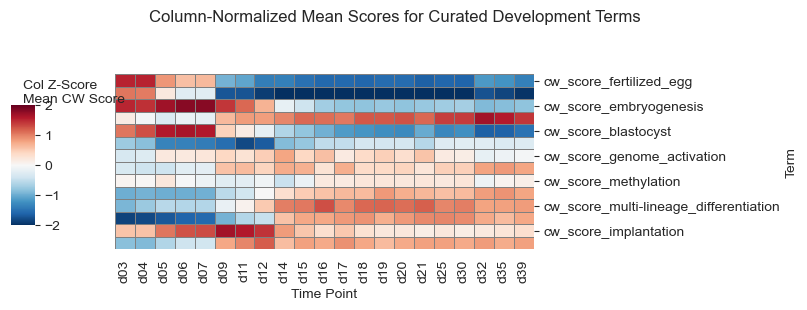

In [47]:
print("\n--- Analyzing Developmental Stage Scores ---")
if 'anno_og_time_days' not in adata.obs.columns:
    warnings.warn("Skipping Developmental Stage Analysis: 'anno_og_time_days' column missing.")
else:
    # --- Simple Development Terms ---
    term_cols_simple = [f"cw_score_{term}" for term in DEVELOPMENT_TERMS_SIMPLE_LOWER if f"cw_score_{term}" in adata.obs.columns]
    if term_cols_simple:
        means_simple = adata.obs.groupby("anno_og_time_days")[term_cols_simple].mean()
        # Sort columns based on d01 score, move zygote to front
        if 'd01' in means_simple.index and not means_simple.loc['d01'].isnull().all():
             sorted_cols = means_simple.columns[np.argsort(means_simple.loc['d01'].values)[::-1]]
             if 'cw_score_zygote' in sorted_cols:
                 means_simple = means_simple[["cw_score_zygote"] + [c for c in sorted_cols if c != "cw_score_zygote"]]
             else:
                 means_simple = means_simple[sorted_cols]

        plot_mean_score_heatmap(means_simple, "Mean CellWhisperer Scores for Simple Development Terms",
                                "dev_terms_simple_heatmap_absolute.pdf", OUTPUT_DIR,
                                normalize=None, cbar_title="Mean CW Score")
        plot_mean_score_heatmap(means_simple, "Row-Normalized Mean Scores for Simple Development Terms",
                                "dev_terms_simple_heatmap_row_norm.pdf", OUTPUT_DIR,
                                normalize='row', cbar_title="Mean CW Score")
        # Z-score calculation requires global stats
        # plot_mean_score_heatmap(zscores_df, "Z-Scored Mean Scores for Simple Development Terms",
        #                         "dev_terms_simple_heatmap_zscore.pdf", OUTPUT_DIR,
        #                         normalize='zscore', cbar_title="Mean CW Score")
      #  for col in term_cols_simple:
      #       plot_umap(adata, col, OUTPUT_DIR, "dev_terms_simple", cmap="RdBu_r", vmin=-0.1, vmax=0.1) # Example vmin/vmax


    # --- Grouped Carnegie terms
    terms_cols_carnegie_grouped = [f"cw_score_{term.replace(' ', '_').replace('.', '').replace(',', '').lower()}" for term in CARNEGIE_GROUPED_TERMS if f"cw_score_{term.replace(' ', '_').replace('.', '').replace(',', '').lower()}" in adata.obs.columns]
    if terms_cols_carnegie_grouped:
        means_carnegie_grouped = adata.obs.groupby("anno_og_time_days")[terms_cols_carnegie_grouped].mean()

        plot_mean_score_heatmap(means_carnegie_grouped, "Mean CellWhisperer Scores for Simple Development Terms",
                                "dev_terms_carnegie_grouped_heatmap_absolute.pdf", OUTPUT_DIR,
                                normalize=None, cbar_title="Mean CW Score")
        plot_mean_score_heatmap(means_carnegie_grouped, "Row-Normalized Mean Scores for Simple Development Terms",
                                "dev_terms_carnegie_grouped_heatmap_row_norm.pdf", OUTPUT_DIR,
                                normalize='row', cbar_title="Mean CW Score")
        plot_mean_score_heatmap(means_carnegie_grouped, "Column-Normalized Mean Scores for Simple Development Terms",
                                "dev_terms_carnegie_grouped_heatmap_col_norm.pdf", OUTPUT_DIR,
                                normalize='col', cbar_title="Mean CW Score")
        # Z-score calculation requires global stats
        # plot_mean_score_heatmap(zscores_df, "Z-Scored Mean Scores for Simple Development Terms",
        #                         "dev_terms_simple_heatmap_zscore.pdf", OUTPUT_DIR,
        #                         normalize='zscore', cbar_title="Mean CW Score")
        # for col in terms_cols_carnegie_grouped:
        #      plot_umap(adata, col, OUTPUT_DIR, "carnegie_grouped", cmap="RdBu_r", vmin=-0.1, vmax=0.1) # Example vmin/vmax

    # --- Curated Development Terms ---
    term_cols_curated = [f"cw_score_{term.replace(' ', '_').replace('.', '').replace(',', '').lower()}" for term in DEVELOPMENT_TERMS_CURATED if f"cw_score_{term.replace(' ', '_').replace('.', '').replace(',', '').lower()}" in adata.obs.columns]
    if term_cols_curated:
        means_curated = adata.obs.groupby("anno_og_time_days")[term_cols_curated].mean()
        if 'd01' in means_curated.index and not means_curated.loc['d01'].isnull().all():
            sorted_cols = means_curated.columns[np.argsort(means_curated.loc['d01'].values)[::-1]]
            zygote_col = f"cw_score_{'zygote'.replace(' ', '_').replace('.', '').lower()}"
            if zygote_col in sorted_cols:
                 means_curated = means_curated[[zygote_col] + [c for c in sorted_cols if c != zygote_col]]
            else:
                 means_curated = means_curated[sorted_cols]

        plot_mean_score_heatmap(means_curated, "Mean CellWhisperer Scores for Curated Development Terms",
                                "dev_terms_curated_heatmap_absolute.pdf", OUTPUT_DIR,
                                normalize=None, cbar_title="Mean CW Score")
        plot_mean_score_heatmap(means_curated, "Row-Normalized Mean Scores for Curated Development Terms",
                                "dev_terms_curated_heatmap_row_norm.pdf", OUTPUT_DIR,
                                normalize='row', cbar_title="Mean CW Score")
        plot_mean_score_heatmap(means_curated, "Column-Normalized Mean Scores for Curated Development Terms",
                                "dev_terms_curated_heatmap_col_norm.pdf", OUTPUT_DIR,
                                normalize='col', cbar_title="Mean CW Score")
    #    for col in term_cols_curated:
    #         plot_umap(adata, col, OUTPUT_DIR, "dev_terms_curated", cmap="RdBu_r", vmin=-0.1, vmax=0.1)


    # --- Carnegie Stage Descriptions ---
    # Function to extract stage number and letter for sorting
    def extract_stage_key(stage_col_name):
        # Extract from column name like 'cw_score_Carnegie_stage_05a'
        match = re.search(r'Carnegie_stage_(\d+)([a-z]*)', stage_col_name)
        if match:
            number_part = int(match.group(1))
            letter_part = match.group(2)
            return (number_part, letter_part)
        return (float('inf'), "") # Default if pattern doesn't match

    carnegie_cols = [col for col in adata.obs.columns if col.startswith("cw_score_carnegie_stage_")]
    if carnegie_cols:
        means_carnegie = adata.obs.groupby("anno_og_time_days")[carnegie_cols].mean()

        # Sort columns by Carnegie stage number/letter
        sorted_carnegie_cols = sorted(means_carnegie.columns, key=extract_stage_key)
        means_carnegie = means_carnegie[sorted_carnegie_cols]

        # Map column names back to original stage names for plotting labels
        col_rename_map = {col: col.replace("cw_score_", "").replace("_", " ") for col in sorted_carnegie_cols}
        means_carnegie_renamed = means_carnegie.rename(columns=col_rename_map)


        plot_mean_score_heatmap(means_carnegie_renamed, "Mean CellWhisperer Scores for Carnegie Stages",
                                "carnegie_stages_heatmap_absolute.pdf", OUTPUT_DIR,
                                normalize=None, cbar_title="Mean CW Score", col_cluster=False, row_cluster=False)
        plot_mean_score_heatmap(means_carnegie_renamed, "Row-Normalized Mean Scores for Carnegie Stages",
                                "carnegie_stages_heatmap_row_norm.pdf", OUTPUT_DIR,
                                normalize='row', cbar_title="Mean CW Score", col_cluster=False, row_cluster=False)
      #  for col in carnegie_cols:
      #       plot_umap(adata, col, OUTPUT_DIR, "carnegie", cmap="RdBu_r", vmin=-0.1, vmax=0.1)

## 7. Germ Layer Correlation

In [48]:
ALL_ORGANS

['blood',
 'cerebrum',
 'heart',
 'intestine',
 'kidney',
 'large intestine',
 'liver',
 'lung',
 'muscle',
 'pancreas',
 'skin',
 'small intestine',
 'spleen',
 'stomach',
 'vasculature']

In [49]:
print("\n--- Analyzing Germ Layer Correlations ---")
germ_layer_cols = [f"cw_score_{layer}" for layer in GERM_LAYERS if f"cw_score_{layer}" in adata.obs.columns]
organ_cols = [f"cw_score_{organ.replace(' ','_')}" for organ in ORGANS_BBI_LOWER if f"cw_score_{organ.replace(' ','_')}" in adata.obs.columns]


--- Analyzing Germ Layer Correlations ---


Saved germ layer correlation heatmap to: output/heatmap_organ_germlayer_cw_score_correlation.pdf


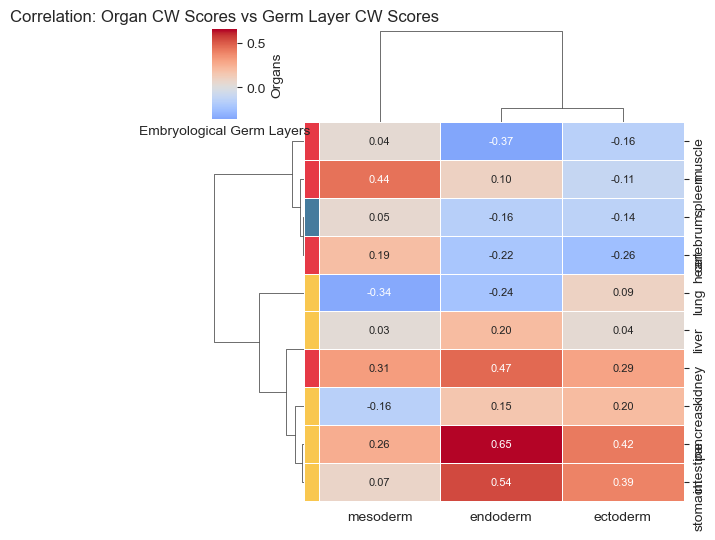

In [50]:
if germ_layer_cols and organ_cols:
    # Extract relevant score columns
    organ_scores_df = adata.obs[organ_cols]
    germ_layer_scores_df = adata.obs[germ_layer_cols]

    # Calculate correlation matrix between organs and germ layers
    # corrwith calculates pairwise correlations between columns of two DataFrames
    # We transpose the result to have organs as rows and germ layers as columns
    # correlation_matrix = organ_scores_df.corrwith(germ_layer_scores_df).T -> This only gives a Series

    # Calculate full correlation matrix and extract the relevant part
    full_df = pd.concat([organ_scores_df, germ_layer_scores_df], axis=1)
    correlation_matrix_full = full_df.corr()
    correlation_matrix = correlation_matrix_full.loc[organ_cols, germ_layer_cols]

    # Clean up row/column names for plotting
    correlation_matrix.index = [idx.replace("cw_score_", "").replace('_',' ') for idx in correlation_matrix.index]
    correlation_matrix.columns = [col.replace("cw_score_", "").replace('_',' ') for col in correlation_matrix.columns]

    # sort organs by germ layer:
    organs_sorted = sorted(ORGAN_GERM_LAYER_ASSOC_DICT.keys(), key=lambda x: ORGAN_GERM_LAYER_ASSOC_DICT[x])
    organs_sorted = [ x for x in organs_sorted if x in ORGANS_BBI_LOWER]

    correlation_matrix=correlation_matrix.loc[organs_sorted]

    row_colors = [ORGAN_COLOR_DICT[organ] for organ in correlation_matrix.index]

    # row-normalize (z) via sklearn
    use_znorm=False
    scaler = StandardScaler()
    correlation_matrix_scaled = scaler.fit_transform(correlation_matrix.T).T
    correlation_matrix_scaled = pd.DataFrame(correlation_matrix_scaled, index=correlation_matrix.index, columns=correlation_matrix.columns)


    # Plot heatmap
    sns.clustermap(correlation_matrix if not use_znorm else correlation_matrix_scaled, annot=True, cmap="coolwarm", center=0,
                linewidths=0.5, fmt=".2f", annot_kws={"size": 8}, row_colors=row_colors,
                row_cluster=True, method="average",metric="correlation" if not use_znorm else "euclidean")
    plt.title("Correlation: Organ CW Scores vs Germ Layer CW Scores")
    plt.xlabel("Embryological Germ Layers")
    plt.ylabel("Organs")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.gcf().set_size_inches(5,5)
    filepath = OUTPUT_DIR / "heatmap_organ_germlayer_cw_score_correlation.pdf"
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Saved germ layer correlation heatmap to: {filepath}")
    plt.show()
    plt.close()
else:
    warnings.warn("Skipping germ layer correlation analysis: Missing required CW score columns.")

## 8. Organ Temporal Emergence Analysis

In [51]:
print("\n--- Analyzing Temporal Emergence of Organs ---")


--- Analyzing Temporal Emergence of Organs ---


In [52]:
# # --- Plot UMAP by Time ---
# if 'anno_og_time_days' in adata.obs.columns:
#      plot_umap(adata, 'anno_og_time_days', OUTPUT_DIR, "time", cmap="viridis") # Viridis often better for time
# else:
#      warnings.warn("Cannot plot UMAP by time: 'anno_og_time_days' missing.")

Saved heatmap to: output/temporal_median_top_cw_score_heatmap.pdf


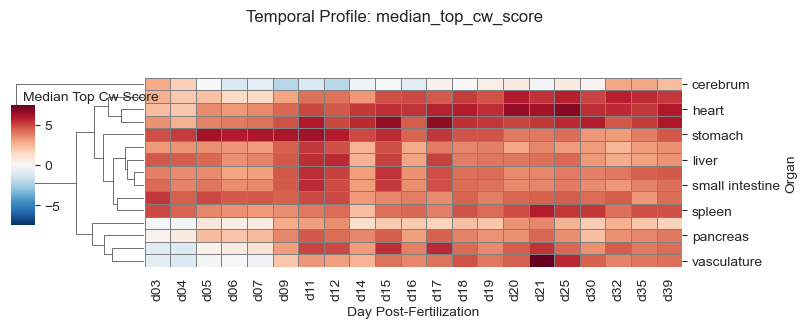

Saved heatmap to: output/temporal_median_top_gene_score_heatmap.pdf


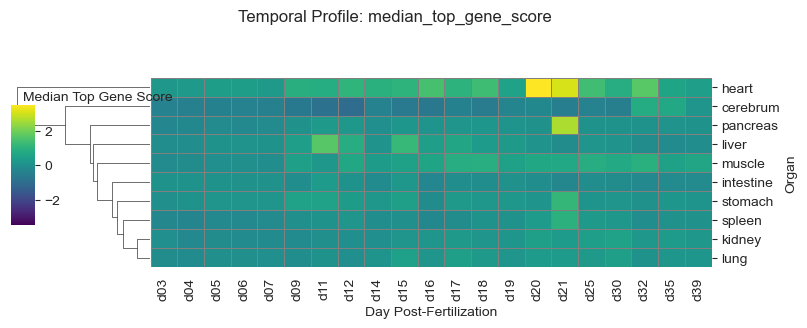

Saved heatmap to: output/temporal_pct_significant_fdr_heatmap.pdf


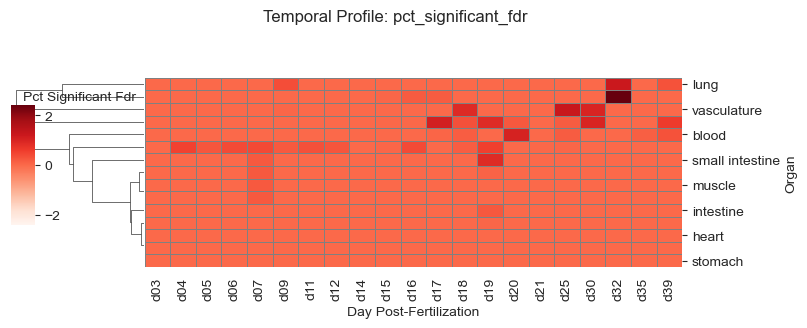

Saved heatmap to: output/temporal_q95_median_diff_heatmap.pdf


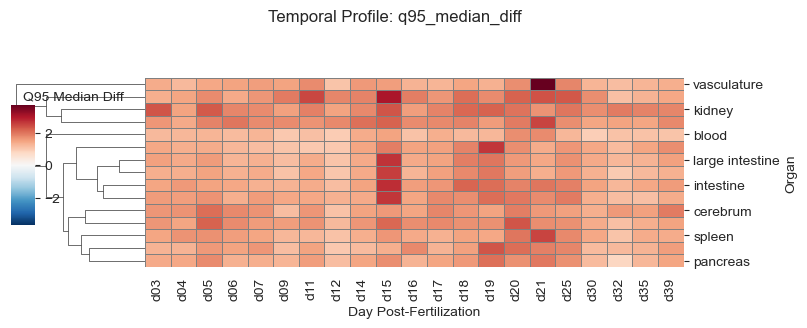

Saved heatmap to: output/temporal_mean_cw_score_heatmap.pdf


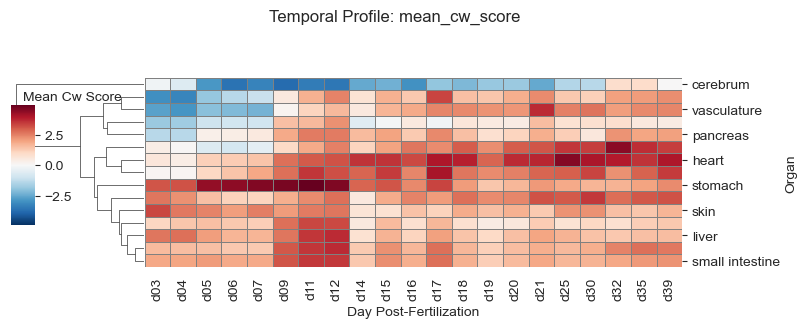

Saved heatmap to: output/temporal_median_cw_score_heatmap.pdf


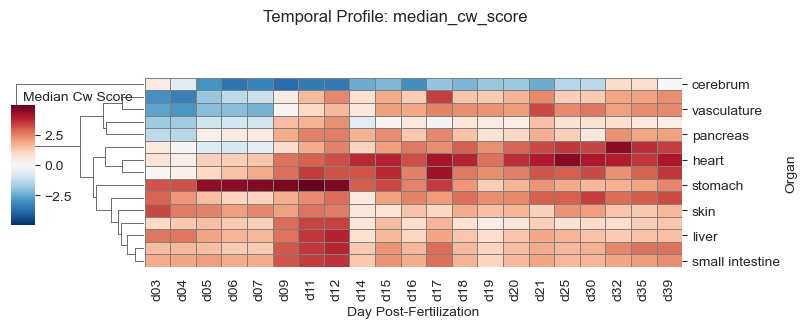

Saved heatmap to: output/temporal_mean_gene_score_heatmap.pdf


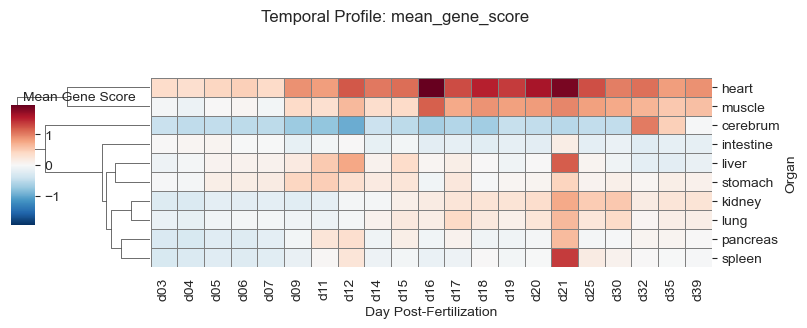

Saved heatmap to: output/temporal_median_gene_score_heatmap.pdf


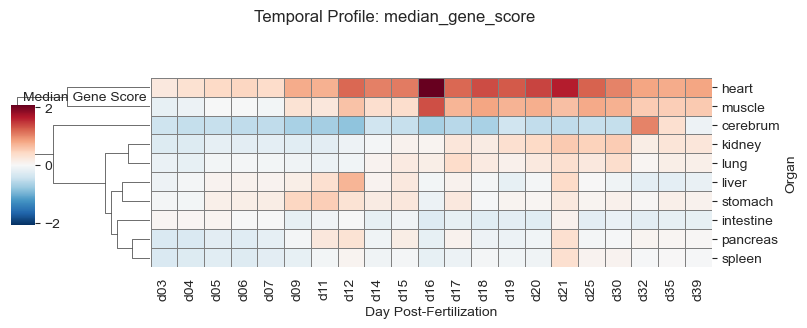

Saved heatmap to: output/temporal_pct_cells_above_threshold_heatmap.pdf


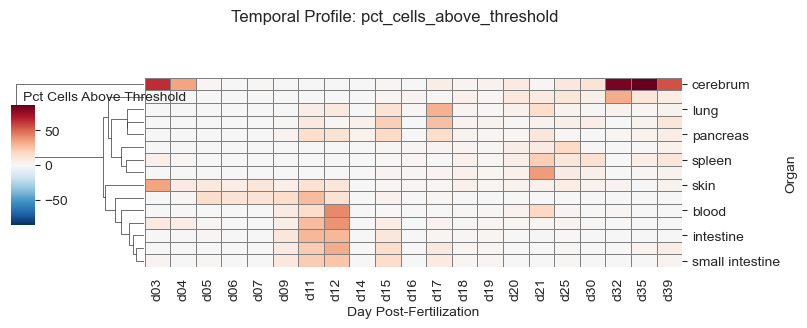

Saved heatmap to: output/temporal_pct_significant_pval_heatmap.pdf


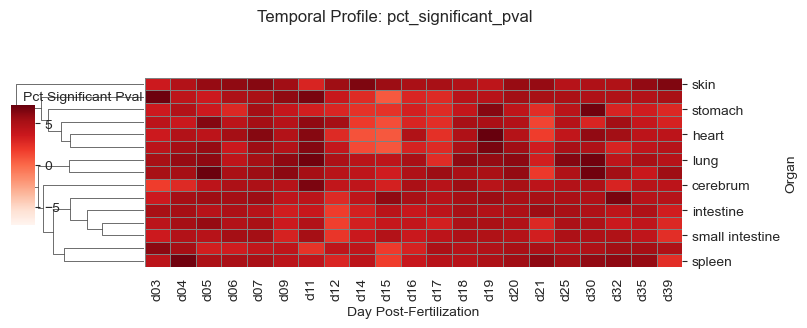

Saved heatmap to: output/temporal_n_cells_above_threshold_heatmap.pdf


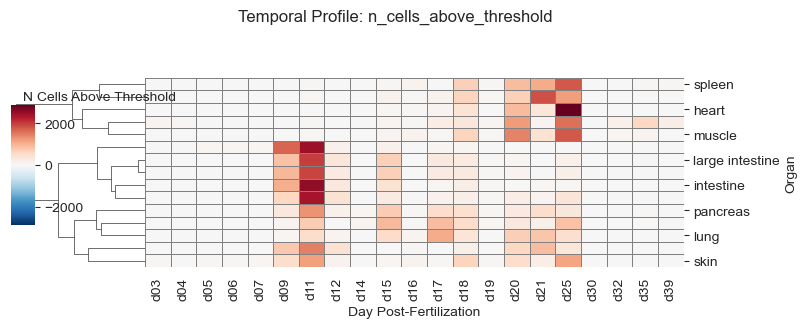

/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/seaborn/matrix.py:615: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, max_dependent_coord * 1.05)


Saved heatmap to: output/temporal_n_cells_heatmap.pdf


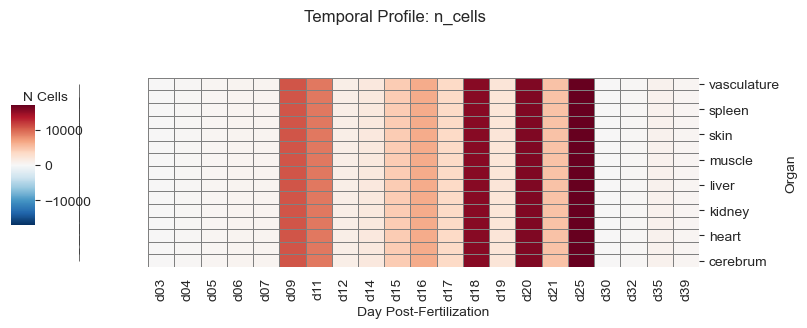

Saved heatmap to: output/temporal_pct_cells_above_threshold_genes_heatmap.pdf


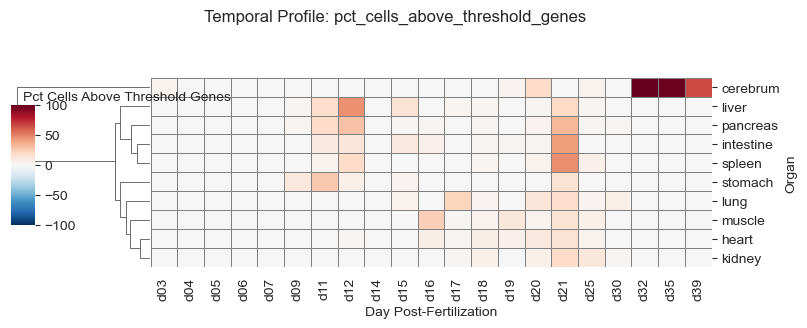

Saved heatmap to: output/temporal_n_cells_above_threshold_genes_heatmap.pdf


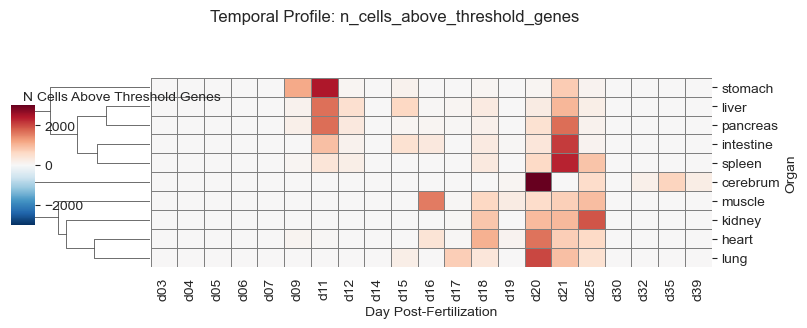

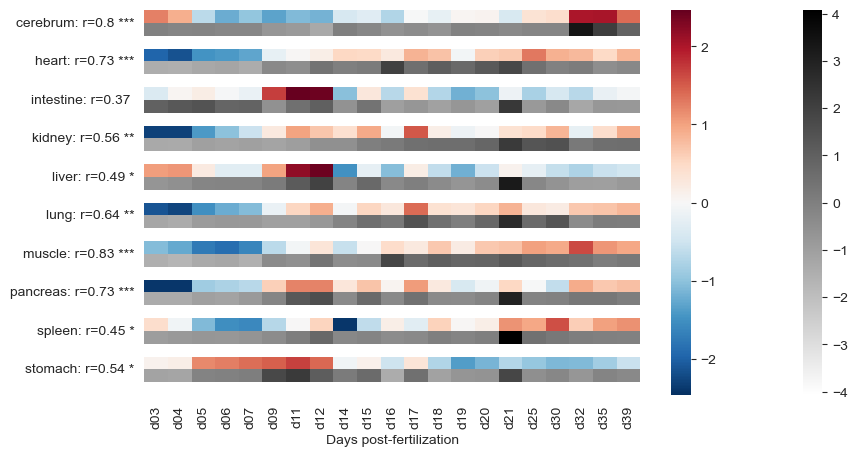

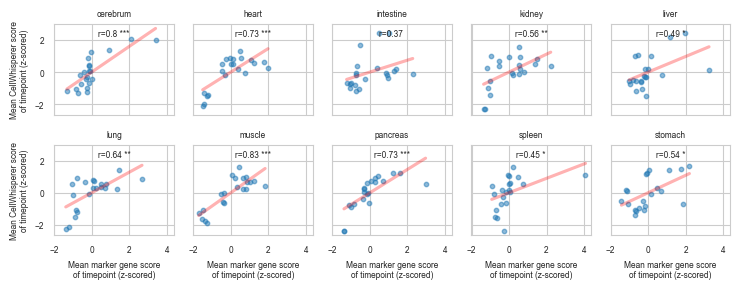

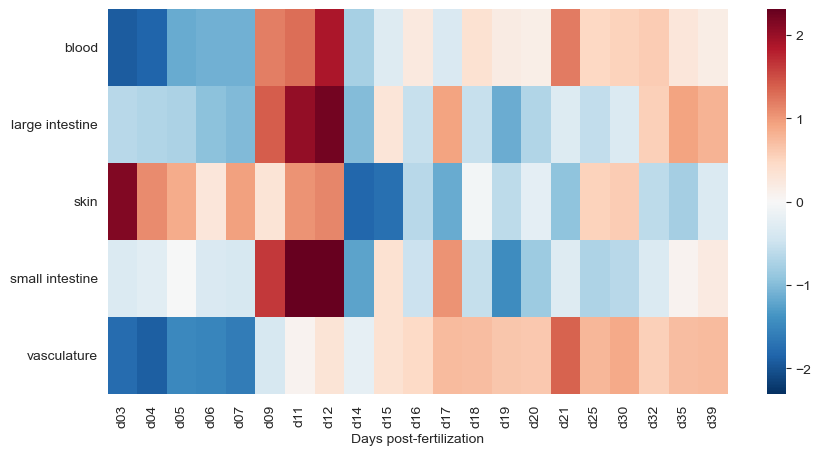

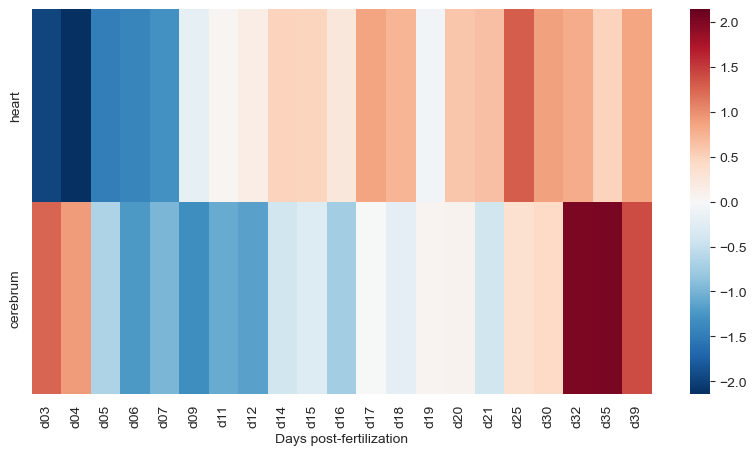

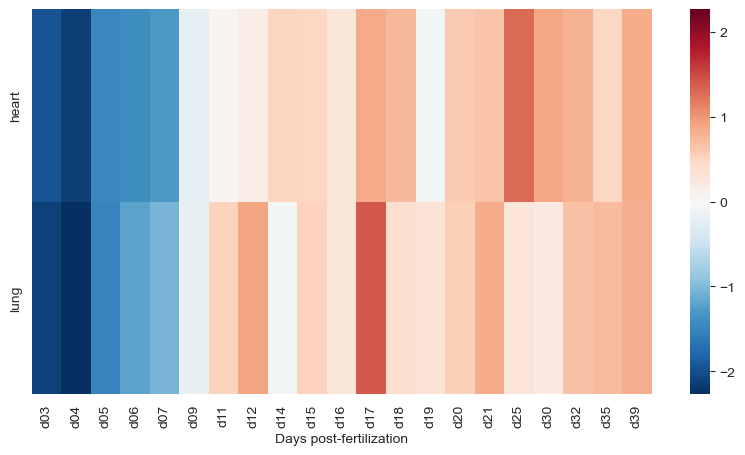

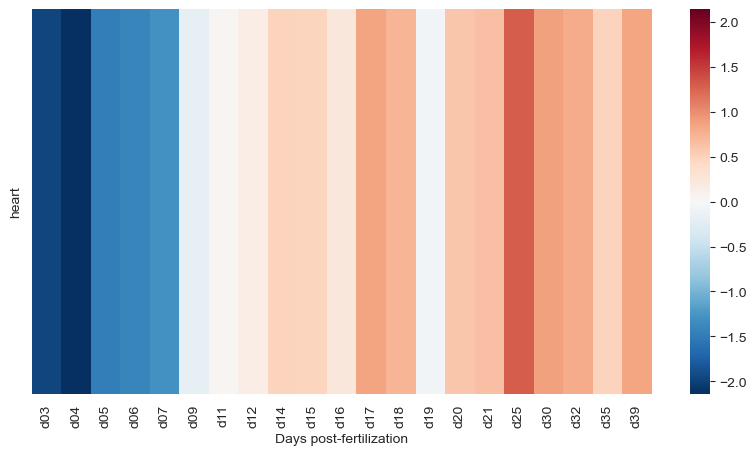

In [53]:
# --- Calculate Timepoint Statistics ---
if 'anno_og_time_days' in adata.obs.columns and organ_cols:
    # Dictionary to store results for each organ
    temporal_stats = defaultdict(lambda: defaultdict(dict))  # organ -> metric -> timepoint -> value

    all_timepoints = sorted(
        adata.obs['anno_og_time_days'].cat.categories
        if pd.api.types.is_categorical_dtype(adata.obs['anno_og_time_days'])
        else sorted(adata.obs['anno_og_time_days'].unique())
    )

    for organ_label in ALL_ORGANS:
        organ_cw_col = f"cw_score_{organ_label.replace(' ','_')}"
        organ_gene_score_col = f"score_{organ_label.replace(' ','_')}_extended"  # Assuming extended score is preferred

        global_q95 = adata.obs[organ_cw_col].quantile(0.95)
        global_gene_q95 = adata.obs[organ_gene_score_col].quantile(0.95) if organ_gene_score_col in adata.obs.columns else None

        for timepoint in all_timepoints:
            adata_timepoint = adata[adata.obs["anno_og_time_days"] == timepoint]

            cw_scores_tp = adata_timepoint.obs[organ_cw_col]
            mean_tp = cw_scores_tp.mean()
            std_tp = cw_scores_tp.std()
            if std_tp > 1e-9:
                score_zscored = (cw_scores_tp - mean_tp) / std_tp
                pvals = 1 - stats.norm.cdf(score_zscored)

                try:
                    reject, fdrs, _, _ = multipletests(pvals, method='fdr_bh')
                except ZeroDivisionError:
                    warnings.warn(f"FDR correction failed for {organ_label} at {timepoint}. Setting FDRs to 1.")
                    fdrs = np.ones_like(pvals)

                pct_above_threshold_fdr = (fdrs < MARKER_FDR_THRESHOLD).sum() / adata_timepoint.shape[0] * 100
                pct_above_threshold_pval = (pvals < MARKER_FDR_THRESHOLD).sum() / adata_timepoint.shape[0] * 100

            top_score_threshold = cw_scores_tp.quantile(CELL_QUANTILE_THRESHOLD)
            top_scores = cw_scores_tp[cw_scores_tp > top_score_threshold]

            temporal_stats[organ_label]["pct_significant_fdr"][timepoint] = pct_above_threshold_fdr
            temporal_stats[organ_label]["pct_significant_pval"][timepoint] = pct_above_threshold_pval
            temporal_stats[organ_label]["median_top_cw_score"][timepoint] = np.median(top_scores) if not top_scores.empty else np.nan
            temporal_stats[organ_label]["median_cw_score"][timepoint] = cw_scores_tp.median()
            temporal_stats[organ_label]["mean_cw_score"][timepoint] = cw_scores_tp.mean()
            temporal_stats[organ_label]["q95_median_diff"][timepoint] = cw_scores_tp.quantile(0.95) - cw_scores_tp.median()
            temporal_stats[organ_label]["pct_cells_above_threshold"][timepoint] = cw_scores_tp[cw_scores_tp > global_q95].shape[0] / adata_timepoint.shape[0] * 100
            temporal_stats[organ_label]["n_cells_above_threshold"][timepoint] = cw_scores_tp[cw_scores_tp > global_q95].shape[0]
            temporal_stats[organ_label]["n_cells"][timepoint] = cw_scores_tp.shape[0]


            if organ_gene_score_col in adata.obs.columns:
                gene_scores_tp = adata_timepoint.obs[organ_gene_score_col]
                top_gene_scores = gene_scores_tp[cw_scores_tp > top_score_threshold]
                median_top_gene_score = np.median(top_gene_scores) if not top_gene_scores.empty else np.nan
                temporal_stats[organ_label]["median_top_gene_score"][timepoint] = median_top_gene_score
                temporal_stats[organ_label]["median_gene_score"][timepoint] = gene_scores_tp.median()
                temporal_stats[organ_label]["mean_gene_score"][timepoint] = gene_scores_tp.mean()
                temporal_stats[organ_label]["pct_cells_above_threshold_genes"][timepoint] = gene_scores_tp[gene_scores_tp > global_gene_q95].shape[0] / adata_timepoint.shape[0] * 100 if global_gene_q95 is not None else np.nan
                temporal_stats[organ_label]["n_cells_above_threshold_genes"][timepoint] = gene_scores_tp[gene_scores_tp > global_gene_q95].shape[0] if global_gene_q95 is not None else np.nan




    metrics_to_plot = ["median_top_cw_score", "median_top_gene_score", "pct_significant_fdr", "q95_median_diff",
                       "mean_cw_score","median_cw_score", "mean_gene_score","median_gene_score", "pct_cells_above_threshold",
                       "pct_significant_pval", "n_cells_above_threshold", "n_cells","pct_cells_above_threshold_genes",
                          "n_cells_above_threshold_genes"]
    temporal_dfs = {}
    for metric in metrics_to_plot:
        df_data = {organ: stats[metric] for organ, stats in temporal_stats.items() if metric in stats}
        if df_data:
            temporal_dfs[metric] = pd.DataFrame(df_data).reindex(all_timepoints)

    # --- Plot Heatmaps of Temporal Statistics ---
    for metric_name, df in temporal_dfs.items():
        if df.empty:
            print(f"Skipping heatmap for {metric_name}: No data.")
            continue

        if metric_name == "median_top_gene_score":
            plot_df = df[ORGANS_BBI_LOWER].dropna(axis=1, how='all')
            cmap = "viridis"
            vmin, vmax = None, None
        elif metric_name.startswith("pct_significant"):
            plot_df = df
            cmap = "Reds"
            vmin, vmax = None, None
        else:
            plot_df = df
            cmap = "RdBu_r"
            score_max = df.max().max()
            score_min = df.min().min()
            abs_max = max(abs(score_min), abs(score_max)) if not pd.isna(score_min) and not pd.isna(score_max) else None
            vmin = -abs_max if abs_max else None
            vmax = abs_max if abs_max else None

        if not plot_df.empty:
            plot_mean_score_heatmap(plot_df, f"Temporal Profile: {metric_name}",
                                    f"temporal_{metric_name}_heatmap.pdf", OUTPUT_DIR,
                                    cmap=cmap, vmin=vmin, vmax=vmax, col_cluster=False, row_cluster=True,
                                    xlabel="Day Post-Fertilization", ylabel="Organ",
                                    cbar_title=metric_name.replace("_", " ").title())
        else:
            print(f"Skipping heatmap for {metric_name}: DataFrame empty after filtering.")

    common_hm_cw_metric = "mean_cw_score"
    common_hm_gene_metric = "mean_gene_score"
    # common_hm_cw_metric="pct_cells_above_threshold"
    # common_hm_gene_metric="pct_cells_above_threshold_genes"
    #common_hm_cw_metric = "median_top_cw_score"
    #common_hm_gene_metric = "median_top_gene_score"

    # --- Combined CW Score vs Gene Score Heatmap (BBI Organs) ---
    if common_hm_cw_metric in temporal_dfs and common_hm_gene_metric in temporal_dfs:
        cw_scores_df = temporal_dfs[common_hm_cw_metric][ORGANS_BBI_LOWER].dropna(axis=1, how='all')
        gene_scores_df = temporal_dfs[common_hm_gene_metric][ORGANS_BBI_LOWER].dropna(axis=1, how='all')

        common_organs = sorted(list(set(cw_scores_df.columns) & set(gene_scores_df.columns)))
        cw_scores_df = cw_scores_df[common_organs].dropna(how='all')
        gene_scores_df = gene_scores_df[common_organs].dropna(how='all')
        common_time = sorted(list(set(cw_scores_df.index) & set(gene_scores_df.index)))
        cw_scores_df = cw_scores_df.loc[common_time]
        gene_scores_df = gene_scores_df.loc[common_time]

        # znorm the cw_scores_df
        #!!!!
        scaler = StandardScaler()
        cw_scores_z = pd.DataFrame(scaler.fit_transform(cw_scores_df),
                                    index=cw_scores_df.index, columns=cw_scores_df.columns)
        cw_scores_df = cw_scores_z

        if not cw_scores_df.empty and not gene_scores_df.empty:
            scaler = StandardScaler()
            gene_scores_z = pd.DataFrame(scaler.fit_transform(gene_scores_df),
                                         index=gene_scores_df.index, columns=gene_scores_df.columns)

            correlation_results = {}
            for organ in common_organs:
                r, pval = stats.pearsonr(gene_scores_df[organ].fillna(0), cw_scores_df[organ].fillna(0))
                correlation_results[organ] = (r, pval)
            
            gene_scores_z.columns=[f"{col}_gene_score" for col in gene_scores_z.columns]

            assert all(gene_scores_z.index == cw_scores_df.index)
            assert all([x.replace("_gene_score", "") for x in gene_scores_z.columns] == cw_scores_df.columns)

            placeholder = gene_scores_z.copy()
            placeholder.columns = [x.replace("_gene_score", "_placeholder") for x in placeholder.columns]

            hm_df = pd.concat([gene_scores_z, cw_scores_df, placeholder], axis=1)
            hm_df = hm_df[sorted(hm_df.columns)]

            for name, scores_df in {"Marker gene score": gene_scores_z, "Cellwhisperer score": cw_scores_df}.items():
                vmin = scores_df.min().min()
                vmax = scores_df.max().max()
                cmap = "viridis"
                if name=="Marker gene score" or ("pct" not in common_hm_cw_metric and "n_cells" not in common_hm_cw_metric):
                    absmax = max(abs(vmin), abs(vmax))
                    vmin = -absmax
                    vmax = absmax
                    cmap="RdBu_r"

                mask = hm_df.copy()
                mask.iloc[:, :] = True
                mask[scores_df.columns] = False

                sns.heatmap(hm_df.T, mask=mask.T, cmap=cmap if name == "Cellwhisperer score" else "binary",
                            vmin=vmin, vmax=vmax, yticklabels=(name == "Cellwhisperer score"),
                            xticklabels=True, linewidths=0)

            pearson_results = []
            for i in range(gene_scores_df.shape[1]):
                r, pval = stats.pearsonr(x=gene_scores_df.iloc[:, i], y=cw_scores_df.iloc[:, i])
                asterisks = ""
                if pval < 0.001:
                    asterisks = "***"
                elif pval < 0.01:
                    asterisks = "**"
                elif pval < 0.05:
                    asterisks = "*"
                pearson_results.append((r, asterisks))

            plt.gca().grid(False)
            plt.gca().patch.set_facecolor('white')

            yticklabels = [f"{organ}: r={round(pearsonres[0], 2)} {pearsonres[1]}" for organ, pearsonres in zip(cw_scores_df.columns, pearson_results)]
            ytickpositions = list(range(1, 3 * len(yticklabels), 3))
            plt.yticks(ytickpositions, yticklabels, rotation=0)
            plt.xlabel("Days post-fertilization")
            plt.gcf().set_size_inches(10, 5)
            plt.savefig(OUTPUT_DIR / "temporal_comparison_gene_vs_cw_heatmap.pdf")
            plt.show()
            plt.close()

            common_df = cw_scores_df.melt(var_name="organ", value_name="cw_score")
            common_df["z_score"] = gene_scores_z.melt(var_name="organ", value_name="z_score")["z_score"]

            # Create subplots - two rows
            n_organs = len(common_organs)
            n_cols = (n_organs + 1) // 2  # Calculate columns needed for 2 rows
            fig, axes = plt.subplots(2, n_cols, figsize=(n_cols*1.5 , 3), sharex=True, sharey=True)

            # Flatten axes array for easier indexing
            axes_flat = axes.flatten()

            for i, organ in enumerate(common_organs):
                organ_data = common_df[common_df["organ"] == organ]
                
                sns.regplot(x="z_score", y="cw_score", data=organ_data, ax=axes_flat[i],
                            scatter_kws={'s': 10, 'alpha': 0.5}, line_kws={'color': 'red',"alpha":0.3},
                            ci=None)
                
                # Annotate the r and p-value on each subplot
                pearsonres = pearson_results[i]
                axes_flat[i].annotate(f"r={round(pearsonres[0], 2)} {pearsonres[1]}",
                                 xy=(0.5, 0.9), xycoords="axes fraction",
                                 ha="center", va="center", fontsize=6)
                
                axes_flat[i].set_title(organ, fontsize=6)
                
                # Only show x labels for bottom row
                if i >= n_organs - n_cols:  # Bottom row
                    axes_flat[i].set_xlabel("Mean marker gene score\nof timepoint (z-scored)", fontsize=6)
                else:
                    axes_flat[i].set_xlabel("")
                
                # Only show y labels for leftmost column
                if i % n_cols == 0:  # First column of each row
                    axes_flat[i].set_ylabel("Mean CellWhisperer score\nof timepoint (z-scored)", fontsize=6)
                else:
                    axes_flat[i].set_ylabel("")
                
                # Set tick label font size
                axes_flat[i].tick_params(axis='both', which='major', labelsize=6)

            # Hide any unused subplots
            for j in range(n_organs, len(axes_flat)):
                axes_flat[j].set_visible(False)

            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / "temporal_comparison_gene_vs_cw_scatter.pdf")
            plt.show()
            plt.close()

            # # --- Scatter plot with individual cell data points ---
            # fig, axes = plt.subplots(1, n_organs, figsize=(20, 4))

            # for i, organ in enumerate(common_organs):
            #     organ_cw_col = f"cw_score_{organ.replace(' ','_')}"
            #     organ_gene_score_col = f"score_{organ.replace(' ','_')}_extended"
                
            #     # Get all cells across all timepoints for this organ
            #     cw_scores_all = adata.obs[organ_cw_col]
            #     gene_scores_all = adata.obs[organ_gene_score_col] if organ_gene_score_col in adata.obs.columns else None
                
            #     if gene_scores_all is not None:
            #         # Remove any NaN values
            #         valid_mask = ~(pd.isna(cw_scores_all) | pd.isna(gene_scores_all))
            #         cw_valid = cw_scores_all[valid_mask]
            #         gene_valid = gene_scores_all[valid_mask]

            #         # zscore the gene scores
            #         gene_valid = (gene_valid - gene_valid.mean()) / gene_valid.std()
                    
            #         sns.regplot(x=gene_valid, y=cw_valid, ax=axes[i],
            #                     scatter_kws={'s': 1, 'alpha': 0.3}, line_kws={'color': 'red'})
                    
            #         # Calculate correlation for all cells
            #         r_all, p_all = stats.pearsonr(gene_valid, cw_valid)
            #         asterisks = ""
            #         if p_all < 0.001:
            #             asterisks = "***"
            #         elif p_all < 0.01:
            #             asterisks = "**"
            #         elif p_all < 0.05:
            #             asterisks = "*"
                    
            #         axes[i].annotate(f"r={round(r_all, 2)} {asterisks}",
            #                          xy=(0.5, 0.9), xycoords="axes fraction",
            #                          ha="center", va="center", fontsize=10)
                    
            #         axes[i].set_title(organ)
            #         axes[i].set_xlabel("Marker Gene Score")
            #         axes[i].set_ylabel("CellWhisperer Score")

            # fig.suptitle("Individual Cell Correlation: Marker Gene Score vs CellWhisperer Score", y=1.05)
            # plt.tight_layout()
            # plt.savefig(OUTPUT_DIR / "individual_cell_gene_vs_cw_scatter.pdf")
            # plt.show()
            # plt.close()

    else:
        print("Skipping Gene vs CW score comparison heatmap: Missing required temporal data.")

    # other organs
    non_bbi_organs=[x for x in ALL_ORGANS if not x in ORGANS_BBI_LOWER]
    for other_organ_list, other_organ_list_name in zip ([non_bbi_organs, ["heart","cerebrum"],["heart", "lung"],["heart"]],["non_bbi_organs","heart_and_cerebrum", "heart_and_lung","heart"]):

        cw_scores_df_other_organs = temporal_dfs[common_hm_cw_metric][other_organ_list].dropna(axis=1, how='all')
        scores_df=cw_scores_df_other_organs

        # zscore
        scaler = StandardScaler()
        scores_z = pd.DataFrame(scaler.fit_transform(scores_df),
                               index=scores_df.index, columns=scores_df.columns)
        scores_df = scores_z

        vmin = scores_df.min().min()
        vmax = scores_df.max().max()
        absmax = max(abs(vmin), abs(vmax))
        vmin = -absmax
        vmax = absmax

        sns.heatmap(scores_df.T, cmap="RdBu_r",
                    vmin=vmin, vmax=vmax, yticklabels=True,
                    xticklabels=True, linewidths=0)

        plt.gca().grid(False)
        plt.gca().patch.set_facecolor('white')

        # yticklabels = other_organ_list
        # ytickpositions = list(range(1, 3 * len(yticklabels), 3))
        # plt.yticks(ytickpositions, yticklabels, rotation=0)
        plt.xlabel("Days post-fertilization")
        plt.gcf().set_size_inches(10, 5)
        plt.savefig(OUTPUT_DIR / f"temporal_comparison_{other_organ_list_name}.pdf")
        plt.show()

else:
    warnings.warn("Skipping Temporal Emergence Analysis: Missing 'anno_og_time_days' or CW score columns.")


In [54]:
adata.obs.batch.unique()

array(['PRJEB30442', 'EMTAB3929', 'EMTAB8060_B1', 'EMTAB8060_B2',
       'PRJEB40781', 'GSE155121', 'GSE232861'], dtype=object)

In [55]:
adata.obs.value_counts(["batch", "anno_og_time_days"]).sort_index()

batch         anno_og_time_days
EMTAB3929     d03                     81
              d04                    190
              d05                    377
              d06                    415
              d07                    466
EMTAB8060_B1  d09                   1975
              d11                   2682
              d12                   1083
EMTAB8060_B2  d09                   8736
              d11                   5405
GSE155121     d15                    618
              d16                   4456
              d17                   3196
              d18                  14420
              d19                   1678
              d20                  15895
              d21                   2402
              d25                  16971
              d30                    102
              d32                    166
              d35                    676
              d39                    328
GSE232861     d11                    841
              d14        

In [56]:
adata

AnnData object with n_obs × n_vars = 95092 × 10000
    obs: 'anno_og', 'age', 'batch', 'instrument', 'institution', 'protocol', 'AvgReadLen', 'country', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'organism_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'tissue_ontology_term_id', 'Clusters', '_X', '_Y', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'anno_og_time', '_scvi_batch', '_scvi_labels', 'anno_og_time_days', 'cw_score_blastocyst', 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_lacunar_vascular_circle', 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_solid_trophoblast', 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_trophoblastic_lacunae', 'cw_score_blastula_stage_during_which_implantation_occ

## 9. CW-Organ Marker Gene Identification & Validation

In [57]:
#ORGANS_BBI_LOWER=["heart", "liver"]

In [58]:
# --- Method 1: Differential Expression on Top Scoring Cells ---

pk_path_genes_m1 = OUTPUT_DIR / 'CW_organs_marker_genes_method1.pickle'
pk_path_dfs_m1 = OUTPUT_DIR / 'CW_organs_marker_genes_dfs_method1.pickle'
pk_path_cells_m1 = OUTPUT_DIR / 'CW_organs_marker_genes_cells_method1.pickle'

if RERUN_M1_MARKER_FINDING or (not pk_path_genes_m1.exists()) or (not pk_path_dfs_m1.exists()) or (not pk_path_cells_m1.exists()):
    print("\n--- Identifying CellWhisperer-based Organ Marker Genes ---")
    print("\n--- Method 1: DE on Top Scoring Cells ---")
    cw_markers_m1 = {}
    cw_dfs_m1 = {}
    cw_cells_m1 = {}
    # Check if required columns exist
    required_obs_cols = [f"cw_score_{org}" for org in ORGANS_BBI_LOWER]
    if not all(col in adata.obs.columns for col in required_obs_cols):
        warnings.warn("Skipping CW Marker Gene Method 1: Missing required CellWhisperer score columns.")
    else:
        for organ in ORGANS_BBI_LOWER:
            cw_col = f"cw_score_{organ}"
            score_threshold = adata.obs[cw_col].quantile(CELL_QUANTILE_THRESHOLD)
            top_scoring_mask = adata.obs[cw_col] > score_threshold

            if top_scoring_mask.sum() < 10: # Need sufficient cells in group for DE
                warnings.warn(f"Skipping DE for {organ} (Method 1): Less than 10 cells found above {CELL_QUANTILE_THRESHOLD:.0%} quantile threshold.")
                continue

            cw_cells_m1[organ] = adata.obs.index[top_scoring_mask].tolist()

            # Define groups for rank_genes_groups
            group_label = f"{organ}_top_vs_rest"
            adata.obs[group_label] = np.where(top_scoring_mask, f"{organ}_top", f"{organ}_rest")
            adata.obs[group_label] = adata.obs[group_label].astype("category")

            print(f"Running DE for {organ} (Method 1): {top_scoring_mask.sum()} top cells vs rest...")
            try:
                # POTENTIAL ISSUE: rank_genes_groups can be memory intensive. Ensure sufficient RAM.
                # Filter genes beforehand if needed.
                sc.tl.rank_genes_groups(adata, group_label, method='wilcoxon',
                                        groups=[f"{organ}_top"], reference=f"{organ}_rest",
                                        n_genes=adata.shape[1], # Get stats for all genes
                                        )

                # Extract results
                # POTENTIAL ISSUE: get.rank_genes_groups_df loads all gene results, can be large.
                de_results_df = sc.get.rank_genes_groups_df(adata, group=f"{organ}_top")

                cw_dfs_m1[organ] = de_results_df.copy() # Store for later use

                # Filter significant up-regulated genes
                significant_markers = de_results_df[
                    (de_results_df['pvals_adj'] < MARKER_FDR_THRESHOLD) &
                    (de_results_df['logfoldchanges'] > MARKER_LOGFC_THRESHOLD)
                ]['names'].tolist()

                cw_markers_m1[organ] = significant_markers
                print(f"Found {len(significant_markers)} marker genes for {organ} (Method 1).")

            except KeyError as e:
                warnings.warn(f"Error during DE for {organ} (Method 1), possibly missing group: {e}")
            except Exception as e:
                warnings.warn(f"Error during DE for {organ} (Method 1): {e}")
            finally:
                # Clean up temporary column
                if group_label in adata.obs.columns:
                    del adata.obs[group_label]

        # Save Method 1 markers
        if cw_markers_m1:
            with open(pk_path_genes_m1, 'wb') as handle:
                pk.dump(cw_markers_m1, handle, protocol=pk.HIGHEST_PROTOCOL)
            print(f"Saved Method 1 marker genes to: {pk_path_genes_m1}")

            with open(pk_path_dfs_m1, 'wb') as handle:
                pk.dump(cw_dfs_m1, handle, protocol=pk.HIGHEST_PROTOCOL)
            print(f"Saved Method 1 DE results to: {pk_path_dfs_m1}")

            with open(pk_path_cells_m1, 'wb') as handle:
                pk.dump(cw_cells_m1, handle, protocol=pk.HIGHEST_PROTOCOL)
            print(f"Saved Method 1 top cells to: {pk_path_cells_m1}")

        
else:
    print(f"Loading Method 1 data from pickled files")
    with open(pk_path_genes_m1, 'rb') as handle:
        cw_markers_m1 = pk.load(handle)
        lens={k: len(v) for k, v in cw_markers_m1.items()}
        print(f"Numbers of marker genes: {lens}")
    with open(pk_path_dfs_m1, 'rb') as handle:
        cw_dfs_m1 = pk.load(handle)
    with open(pk_path_cells_m1, 'rb') as handle:
        cw_cells_m1 = pk.load(handle)
    

Loading Method 1 data from pickled files
Numbers of marker genes: {'cerebrum': 670, 'heart': 321, 'intestine': 1252, 'kidney': 492, 'liver': 971, 'lung': 725, 'muscle': 410, 'pancreas': 650, 'spleen': 597, 'stomach': 1414}


In [59]:
# --- Method 2: Correlation between Gene Expression and CW Score ---
pk_path_genes_m2 = OUTPUT_DIR / 'CW_organs_marker_genes_method2.pickle'
m2_corr_df_path = OUTPUT_DIR / 'CW_organs_marker_genes_method2_corr_df.csv'

if RERUN_M2_MARKER_FINDING or (not m2_corr_df_path.exists()):
        
    print("\n--- Method 2: Correlation with CW Score ---")

    cw_markers_m2 = {}
    if not all(col in adata.obs.columns for col in required_obs_cols):
        warnings.warn("Skipping CW Marker Gene Method 2: Missing required CellWhisperer score columns.")
    else:

        m2_corr_vals = {}
        # Consider using processed, normalized data (e.g., adata.X after log1p and scaling)
        # Check if adata.X is sparse
        if issparse(adata.X):
            gene_expressions = adata.X.toarray() # Densify for correlation; POTENTIAL ISSUE: Memory intensive!
            warnings.warn("Densifying sparse adata.X for correlation calculation (Method 2). This may require significant memory.")
        else:
            gene_expressions = adata.X # Cells x Genes

        gene_expressions = gene_expressions.T # Genes x Cells

        gene_names = adata.var_names.tolist()

        for organ in ORGANS_BBI_LOWER:
            cw_col = f"cw_score_{organ}"
            cw_organ_scores = adata.obs[cw_col].values

            if CORR_METHOD=="pearson":
                # Calculate Pearson correlation for all genes against this organ's score
                # Ensure dimensions are correct: (n_genes, n_cells) and (n_cells,)
                # np.corrcoef expects rows to be variables, columns observations.
                # We want correlation between each gene (row in gene_expressions) and cw_organ_scores.
                # A more efficient way for one vector vs many rows:
                mean_expr = np.mean(gene_expressions, axis=1, keepdims=True)
                mean_score = np.mean(cw_organ_scores)
                std_expr = np.std(gene_expressions, axis=1, keepdims=True)
                std_score = np.std(cw_organ_scores)

                # Handle zero standard deviation
                valid_mask = (std_expr > 1e-9).flatten() & (std_score > 1e-9)
                if not valid_mask.any():
                    warnings.warn(f"Skipping correlation for {organ} (Method 2): Zero standard deviation in scores or all genes.")
                    corr_values = np.full(len(gene_names), np.nan)
                else:
                    # Calculate covariance and then correlation only for valid genes
                    cov = np.dot(gene_expressions[valid_mask, :] - mean_expr[valid_mask], cw_organ_scores - mean_score) / (adata.shape[0] - 1)
                    correlations_valid = cov / (std_expr[valid_mask].flatten() * std_score)

                    # Fill in results
                    corr_values = np.full(len(gene_names), np.nan)
                    corr_values[valid_mask] = correlations_valid
                    
            elif CORR_METHOD=="kendall":
                # Calculate Kendall correlation
                corr_values=[]
                for i in range(gene_expressions.shape[0]):
                    corr, _ = stats.kendalltau(gene_expressions[i], cw_organ_scores)
                    corr_values.append(corr)    
                # turn into array
                corr_values = np.array(corr_values)   
            else:
                raise ValueError(f"Unsupported correlation method: {CORR_METHOD}. Use 'pearson' or 'kendall'.")

            m2_corr_vals[organ] = corr_values 

            # Filter genes by correlation threshold
            marker_indices = np.where(corr_values > MARKER_CORR_THRESHOLD)[0]
            significant_markers = [gene_names[i] for i in marker_indices]
            cw_markers_m2[organ] = significant_markers
            print(f"Found {len(significant_markers)} marker genes for {organ} (Method 2) with r > {MARKER_CORR_THRESHOLD}.")

        m2_corr_df= pd.DataFrame(m2_corr_vals, index=gene_names)

        # Save Method 2 markers
        if cw_markers_m2:
            pk_path_m2 = OUTPUT_DIR / f'CW_organs_marker_genes_method2.{CORR_METHOD}.pickle'
            with open(pk_path_m2, 'wb') as handle:
                pk.dump(cw_markers_m2, handle, protocol=pk.HIGHEST_PROTOCOL)
            print(f"Saved Method 2 marker genes to: {pk_path_m2}")

        # Save correlation values
        m2_corr_df.to_csv(m2_corr_df_path)
else:
    # print(f"Loading Method 2 data from pickled files")
    # with open(pk_path_genes_m2, 'rb') as handle:
    #     cw_markers_m2 = pk.load(handle)
    #     lens={k: len(v) for k, v in cw_markers_m2.items()}
    #     print(f"Numbers of marker genes: {lens}")
    # load correlation values
    m2_corr_df = pd.read_csv(m2_corr_df_path, index_col=0)

Saved overlap statistics to: output/gene_overlap_stats_M1.csv
Saved overlap plot to: output/gene_overlap_Jaccard_M1.pdf


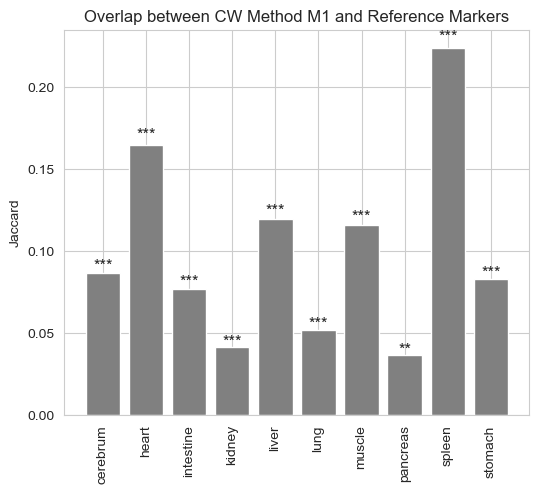

Saved overlap plot to: output/gene_overlap_LogOddsRatio_M1.pdf


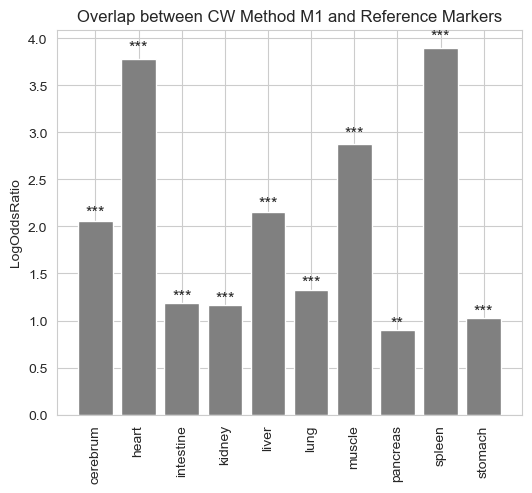

Saved Venn diagrams to: output/venn_diagrams_M1

--- Enrichment Analysis for CW-Only Genes (Method M1) ---
Running enrichment for 585 CW-only genes in cerebrum...


/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Running enrichment for 205 CW-only genes in heart...


/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Running enrichment for 1124 CW-only genes in intestine...


...

Running enrichment for 392 CW-only genes in spleen...


/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Running enrichment for 1256 CW-only genes in stomach...


/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Saved enrichment plots to: output/enrichment_plots_M1


In [60]:
# Validate Method 1 markers
overlaps_m1, cw_only_m1 = validate_and_plot_markers(cw_markers_m1, organ_extended_marker_genes_dict, BACKGROUND_GENE_SET_SIZE, OUTPUT_DIR, "M1",ENRICHMENT_LIBRARIES)

In [61]:
# Validate Method 2 markers
#overlaps_m2, cw_only_m2 = validate_and_plot_markers(cw_markers_m2, organ_extended_marker_genes_dict, BACKGROUND_GENE_SET_SIZE, OUTPUT_DIR, "M2",ENRICHMENT_LIBRARIES)

## 10. Literature Analysis (PubMed)

POTENTIAL ISSUE: This section relies heavily on external calls to NCBI Entrez.
It's slow, requires an internet connection, and is subject to rate limits.
Consider using pre-compiled gene-literature databases or running this section separately.

In [62]:
print("\n--- Performing Literature Analysis (PubMed Search) ---")
Entrez.email = PUBMED_EMAIL
Entrez.api_key = PUBMED_API_KEY


if PUBMED_EMAIL == "your_email@example.com":
    warnings.warn("PubMed email not set. Using default, which is discouraged.")


--- Performing Literature Analysis (PubMed Search) ---


In [63]:
csv_path_literature_results= OUTPUT_DIR / 'literature_search_results.csv'
csv_path_literature_results_w_pmids= OUTPUT_DIR / 'literature_search_results_w_pmids.csv'
if RERUN_LITERATURE_SEARCH or (not csv_path_literature_results.exists()):
    literature_df,literature_df_w_pmids = perform_literature_search(adata.var.index.to_list(), ORGANS_BBI_LOWER, csv_path_lens=csv_path_literature_results,
                                              csv_paths_pmids=csv_path_literature_results_w_pmids,
                                              PUBMED_RATE_LIMIT_DELAY=PUBMED_RATE_LIMIT_DELAY,)
else:
    print(f"Loading literature search results from: {csv_path_literature_results}")
    literature_df = pd.read_csv(csv_path_literature_results, index_col=0)
    literature_df_w_pmids = pd.read_csv(csv_path_literature_results_w_pmids, index_col=0)

Loading literature search results from: output/literature_search_results.csv


In [64]:
for organ in ORGANS_BBI_LOWER:
    literature_df[f"{organ}: log10(Number of papers + 1)"] = literature_df[f"{organ}: Number of PMIDs"].apply(lambda x : np.log10(x+1))

In [65]:
# Create a single dataframe with per-gene results
for organ, df in cw_dfs_m1.items():
    cw_dfs_m1[organ].columns = [f"{organ}: {x}" if not x=="names" else x for x in cw_dfs_m1[organ].columns ]
    cw_dfs_m1[organ]=cw_dfs_m1[organ].sort_values(by="names")
    cw_dfs_m1[organ]=cw_dfs_m1[organ].set_index("names")
de_df= pd.concat(cw_dfs_m1.values(), axis=1)

genes_df = pd.merge(literature_df,de_df, left_index=True, right_index=True, how='outer')
m2_corr_df.columns = [f"{x}: Correlation to CW score" for x in m2_corr_df.columns] 
#m2_corr_df.columns = [x.replace(" : Correlation to CW score","") for x in m2_corr_df.columns] 

genes_df = pd.merge(genes_df, m2_corr_df, left_index=True, right_index=True, how='outer')



In [66]:
genes_df.head()

,cerebrum: Number of PMIDs,heart: Number of PMIDs,intestine: Number of PMIDs,kidney: Number of PMIDs,liver: Number of PMIDs,lung: Number of PMIDs,muscle: Number of PMIDs,pancreas: Number of PMIDs,spleen: Number of PMIDs,stomach: Number of PMIDs,...,cerebrum: Correlation to CW score,heart: Correlation to CW score,intestine: Correlation to CW score,kidney: Correlation to CW score,liver: Correlation to CW score,lung: Correlation to CW score,muscle: Correlation to CW score,pancreas: Correlation to CW score,spleen: Correlation to CW score,stomach: Correlation to CW score
A1BG,0,8,3,6,20,7,3,1,1,1,...,-0.205980,-0.173419,0.105250,-0.013908,0.012523,0.012991,-0.184232,0.084524,-0.202030,0.137773
A1CF,0,3,9,11,20,5,2,0,0,0,...,0.234895,0.185274,-0.098195,0.086886,0.014435,0.190843,0.116116,0.019412,-0.023440,-0.107497
A2M,7,35,16,30,87,51,35,12,8,10,...,0.274724,0.201731,-0.055224,0.089220,0.093505,0.192933,0.231137,0.004197,0.201325,-0.156042
A2ML1,1,8,0,4,3,5,0,0,0,0,...,-0.106436,-0.071396,0.209045,0.130898,0.153978,-0.078565,-0.266239,0.140996,-0.182920,0.297723
A4GALT,0,4,2,10,4,0,1,0,3,1,...,-0.257067,-0.272005,0.242037,0.030000,0.136558,-0.013762,-0.384509,0.148017,-0.287430,0.347788


/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or 

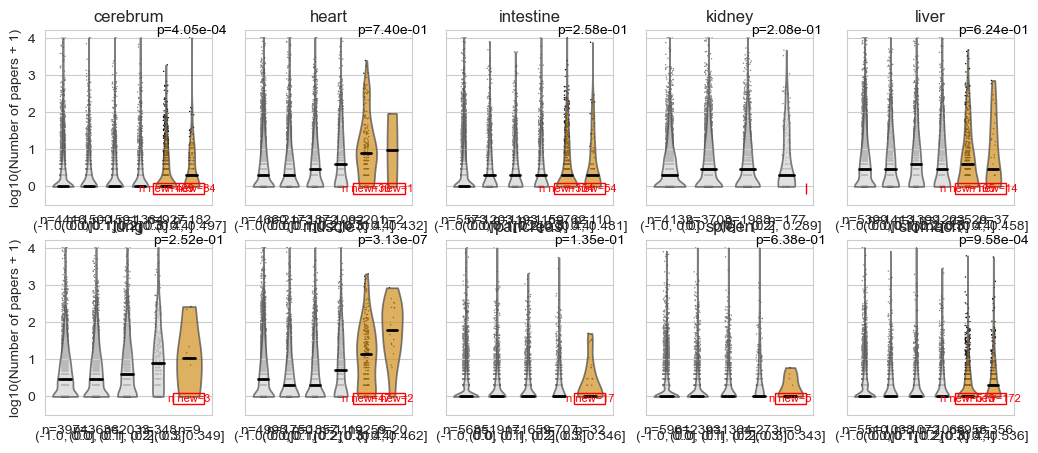

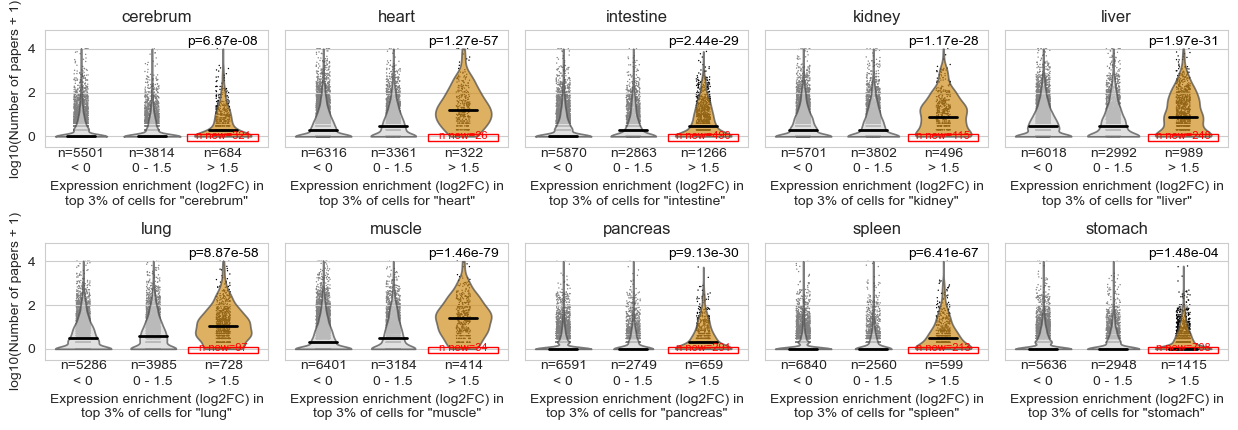

<Figure size 640x480 with 0 Axes>

In [67]:
# Calculate rows and columns for subplots
n_organs = len(ORGANS_BBI_LOWER)
n_cols = (n_organs + 1) // 2  # Round up division
n_rows = 2

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(2.5*n_cols, 2.5*n_rows), sharey=True)
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(2.5*n_cols, 2.2*n_rows), sharey=True)

# Flatten axes arrays for easier iteration
axes1 = axes1.flatten()
axes2 = axes2.flatten()

sns.set_style("ticks")

for i, organ in enumerate(ORGANS_BBI_LOWER):
    ax1 = axes1[i]
    ax2 = axes2[i]
    sns.set_style("ticks")

    base_bins=[-1,0,0.1,0.2]
    box_width_correlation=0
    if genes_df[f"{organ}: Correlation to CW score"].max()>0.3:
        base_bins+=[0.3]
        box_width_correlation+=1
    if genes_df[f"{organ}: Correlation to CW score"].max()>0.4:
        base_bins+=[0.4]
        box_width_correlation+=1

    bins_per_metric={
            f"{organ}: Correlation to CW score":base_bins+[genes_df[f"{organ}: Correlation to CW score"].max()],
            f"{organ}: logfoldchanges":[genes_df[f"{organ}: logfoldchanges"].min(),0,MARKER_LOGFC_THRESHOLD,genes_df[f"{organ}: logfoldchanges"].max()],
    # f"{organ}: logfoldchanges":[genes_df[f"{organ}: logfoldchanges"].min(),0,1,2,genes_df[f"{organ}: logfoldchanges"].max()],
    }
    cutoffs_per_metric = {
        f"{organ}: Correlation to CW score":0.3,
        f"{organ}: logfoldchanges":MARKER_LOGFC_THRESHOLD,
    }

    # start coords and width
    box_per_metric = {
        f"{organ}: Correlation to CW score":((3.5, -0.21), box_width_correlation),
        # f"{organ}: logfoldchanges":((2.5, -0.15), 1),
        f"{organ}: logfoldchanges":((1.5, -0.21), 1),
    }

    for metric in [f"{organ}: Correlation to CW score",f"{organ}: logfoldchanges"]:

        if metric==f"{organ}: Correlation to CW score":
            plt.sca(ax1)
        else:
            plt.sca(ax2)
        color_cutoff_col=metric
        paper_col=f"{organ}: log10(Number of papers + 1)"
            
        genes_df["bin"] = pd.cut(genes_df[metric], bins=bins_per_metric[metric])
        genes_df["above_color_cutoff"] = genes_df[metric] >= cutoffs_per_metric[metric]

        def get_category(row):
            if row[color_cutoff_col] >= cutoffs_per_metric[metric]:
                if row[paper_col]==0:
                    return "above cutoff and new"
                else:
                    return "above cutoff and known"
            else:
                return "below cutoff"

        genes_df[f"{metric}: category"] = genes_df.apply(get_category, axis=1)

        plt.gca().set_rasterization_zorder(0.001)

        sns.set_style("ticks")

        sns.stripplot(data=genes_df, x="bin", y=paper_col, ax=plt.gca(), jitter=True, hue=f"{metric}: category", size=1, dodge=False, 
                        palette={"above cutoff and new":"red","above cutoff and known":"black", "below cutoff":"grey"},
                        zorder=0)
        sns.violinplot(data=genes_df, x="bin", y=paper_col, ax=plt.gca(),inner=None, hue="above_color_cutoff", palette={True:"#ee9703",False:"lightgrey"}, alpha=0.7, cut=0,dodge=False,
                       zorder=1)    
        
        if metric==f"{organ}: logfoldchanges":
            plt.gca().set_xticklabels(["< 0",f"0 - {MARKER_LOGFC_THRESHOLD}", f"> {MARKER_LOGFC_THRESHOLD}"])
            plt.xlabel(f'Expression enrichment (log2FC) in\ntop {int((1-CELL_QUANTILE_THRESHOLD)*100)}% of cells for "{organ}"')
        else:
            plt.xlabel("")

        
        # Add median lines
        for j, bin in enumerate(genes_df["bin"].cat.categories):
            median = genes_df[genes_df["bin"]==bin][paper_col].median()
            plt.plot([j-0.2, j+0.2], [median, median], color="black", linewidth=2)

            
            # write N numbers underneith
            N = genes_df[genes_df["bin"]==bin].shape[0]
            plt.text(j, -1.08, f"n={N}", fontsize=10, ha='center', va='bottom')


            plt.gca().tick_params(axis='x', pad=8)
            # remove the ticks, keep the labels
            plt.gca().tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True)


            no_ref_df= genes_df[(genes_df["bin"]==bin) & (genes_df[paper_col]==0)]
            n_no_ref = no_ref_df.shape[0]
            if genes_df[(genes_df["bin"]==bin) & (genes_df["above_color_cutoff"]==True)].shape[0] > 0:
                plt.text(j, -0.2, f"n new={n_no_ref}", fontsize=8, ha='center', va='bottom', color="red")

            # test for significance vs the first bin
            ref_bin=genes_df["bin"].cat.categories[0]
            last_bin=genes_df["bin"].cat.categories[-1]
            if bin == last_bin:
                ref_papers_log1p= genes_df[genes_df["bin"]==ref_bin][paper_col].values
                test_papers_log1p= genes_df[genes_df["bin"]==bin][paper_col].values

                if ref_papers_log1p.size == 0 or test_papers_log1p.size == 0:
                    print(f"Skipping significance test for bin {bin} vs {ref_bin}: one of the bins is empty")
                    continue
                # test for significance (Mann-Whitney U test)
                u_stat, pval = stats.mannwhitneyu(ref_papers_log1p, test_papers_log1p, alternative="two-sided")
                plt.text(j, genes_df[paper_col].max()*1.01, f"p={pval:.2e}", fontsize=10, ha='center', va='bottom', color="black")

        plt.title(organ)
        plt.ylabel(paper_col.replace(f"{organ}: ",""))

        start_box, width_box = box_per_metric[metric]
        rect = patches.Rectangle(start_box, width_box, 0.3, linewidth=1, edgecolor='red', facecolor="none")
        plt.gca().add_patch(rect)
        
        # remove legend
        plt.legend([],[], frameon=False)
        plt.ylim(-0.5, plt.gca().get_ylim()[1])

# Hide empty subplots if number of organs is odd
if n_organs % 2 != 0:
    axes1[-1].set_visible(False)
    axes2[-1].set_visible(False)

plt.figure(fig2.number)
ylim_lower, ylim_upper = plt.ylim()
plt.ylim(ylim_lower, ylim_upper * 1.15)  # Increase upper limit by 10%


plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"npapers_vs_logfoldchanges.violinplots.pdf", dpi=700, bbox_inches='tight')
plt.show()
plt.close()

plt.figure(fig1.number)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"npapers_vs_Correlation_to_CW_score.violinplots.pdf", dpi=700, bbox_inches='tight')
plt.show()
plt.close()




In [68]:
adata

AnnData object with n_obs × n_vars = 95092 × 10000
    obs: 'anno_og', 'age', 'batch', 'instrument', 'institution', 'protocol', 'AvgReadLen', 'country', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'organism_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'tissue_ontology_term_id', 'Clusters', '_X', '_Y', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'anno_og_time', '_scvi_batch', '_scvi_labels', 'anno_og_time_days', 'cw_score_blastocyst', 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_lacunar_vascular_circle', 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_solid_trophoblast', 'cw_score_blastula_stage_during_which_implantation_occurs_defined_by_a_trophoblastic_lacunae', 'cw_score_blastula_stage_during_which_implantation_occ

In [69]:
developmental_diseases_dict=get_developmental_diseases_dict(DISEASE_DATA_DIR,DISEASE_ZIP,PEDIATRIC_CANCER_GENES_PATH,adata)

Loaded 870 genes for bone_development (available in data).
Loaded 548 genes for congenital_heart (available in data).
Loaded 77 genes for congenital_myopathy (available in data).
Loaded 26 genes for fetal_akinesia (available in data).
Loaded 175 genes for fetal_diseases (available in data).
Loaded 507 genes for newborn_diseases (available in data).
Loaded 19 genes for language_development (available in data).
Loaded 2766 genes for neurodevelopmental (available in data).
Loaded 222 pediatric cancer genes (available in data).


In [70]:
cutoffs_per_metric = {
    f"Correlation to CW score":0.3,
    f"logfoldchanges":MARKER_LOGFC_THRESHOLD,
}

for metric in ["logfoldchanges",f"Correlation to CW score"]:

    # Define genes to be tested
    strongDEgenes_per_organ={organ:genes_df[genes_df[f"{organ}: {metric}"]>cutoffs_per_metric[metric]].index.tolist() for organ in ORGANS_BBI_LOWER }

    # Run overlap analysis
    enrichments, _ = run_disease_enrichment(strongDEgenes_per_organ, developmental_diseases_dict, BACKGROUND_GENE_SET_SIZE)

    enrichments.to_csv(OUTPUT_DIR / f"disease_enrichments_{metric}.csv")

    genes_df[f"Associated with any disease"]=False
    for disease_name, disease_genes in developmental_diseases_dict.items():
        genes_df[f"Associated with {disease_name}"]=False
        genes_df.loc[disease_genes, f"Associated with {disease_name}"]=True
        genes_df.loc[disease_genes, "Associated with any disease"]=True

    # # Add the overlap info to the DF (annotate which gene was found in which disease)
    # overlaps_merged_df= pd.concat([x.reset_index() for x in overlaps.values()], ignore_index=True)
    # for disease in overlaps_merged_df["Disease"].unique():
    #     genes_df[f"Associated with {disease}"]=False
    #     associated_genes=overlaps_merged_df[overlaps_merged_df["Disease"]==disease]["Gene"].values.tolist()
    #     genes_df.loc[associated_genes, f"Associated with {disease}"]=True
    #     genes_df.loc[associated_genes, "Associated with any disease"]=True

    genes_df[f"Max across organs: {metric}"]=genes_df[[x for x in genes_df.columns if x in [f"{organ}: {metric}" for organs in ORGANS_BBI_LOWER]]].max(axis=1)


genes_df["Hit"]=False
genes_df["Hit metrics"]=[[] for _ in range(len(genes_df))]
for col in [x for x in genes_df.columns if "category" in x]:
    selector=(genes_df[col]=="above cutoff and new") & (genes_df["Associated with any disease"])
    genes_df.loc[selector, "Hit"]=True
    genes_df.loc[selector, "Hit metrics"].apply(lambda x: x.append(col))


for col in ["category", "bin",	"above_color_cutoff",	"above_color_cutoff_and_new"]:
    if col in genes_df:
        # kick it out:
        genes_df=genes_df.drop(col, axis=1)

days_expression_df = get_highest_expression_day(adata)
# drop all cols from days_expression_df:
genes_df=genes_df[[x for x in genes_df.columns if not x in days_expression_df.columns]]
genes_df=genes_df.merge(days_expression_df, left_index=True, right_index=True)

# Save the gene info df
genes_df.to_excel(OUTPUT_DIR / f"genes_info_DE_literature_diseases.v3.xlsx", index=True)

# interesting_hits = genes_df.loc[(genes_df["Associated with any disease"]) & (genes_df["Num_Papers"]==0)]
# interesting_hits.to_excel(OUTPUT_DIR / "interesting_hits.xlsx", index=False)



In [71]:
enrichments

pval       fdr
bone_development cerebrum   0.022692  0.141387
                 heart      0.000004  0.000119
                 intestine  0.999858  1.000000
                 liver      0.990727  1.000000
                 lung       1.000000  1.000000
...                              ...       ...
pediatric_cancer lung       1.000000  1.000000
                 muscle     0.003729  0.037759
                 pancreas   1.000000  1.000000
                 spleen     1.000000  1.000000
                 stomach    0.698264  1.000000

[81 rows x 2 columns]

In [72]:
genes_df.to_excel(OUTPUT_DIR / f"genes_info_DE_literature_diseases.v3.xlsx", index=True)

/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or 

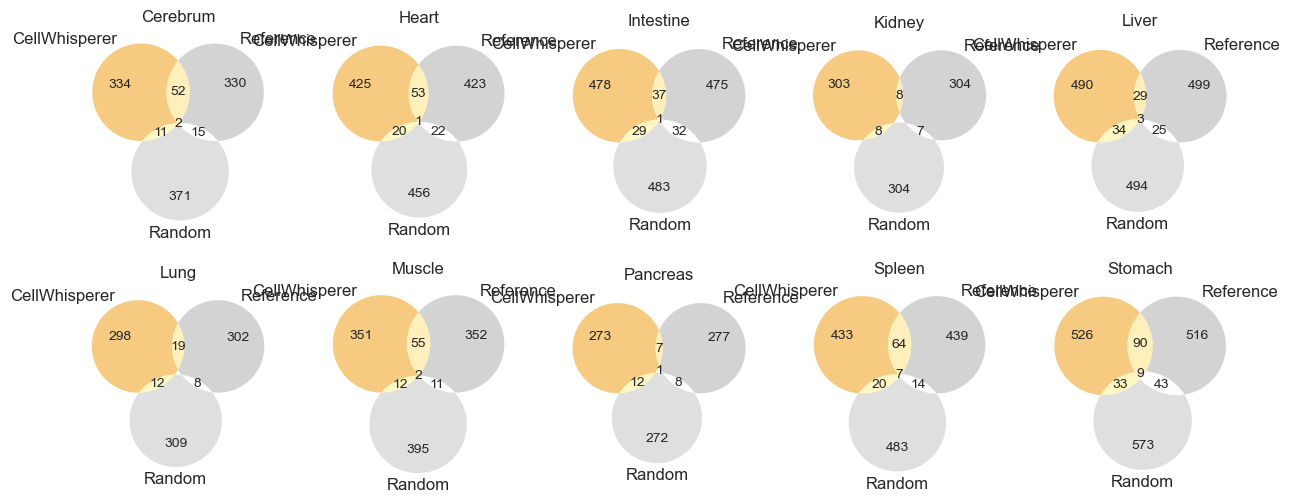

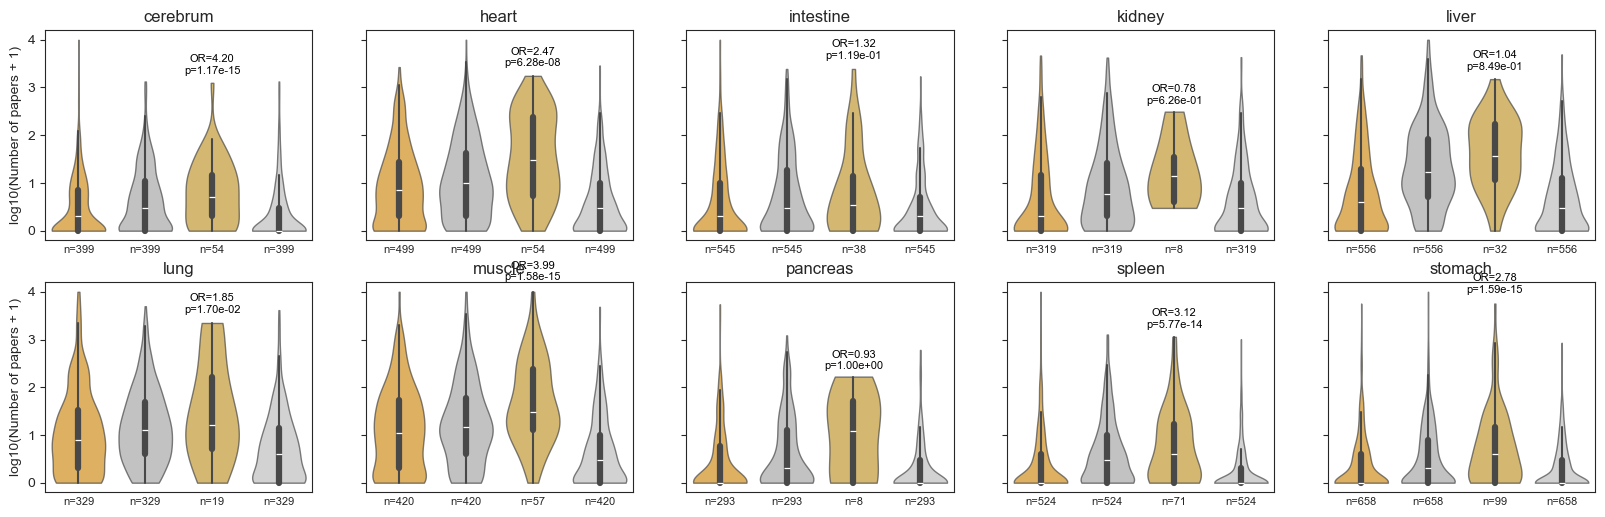

/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or 

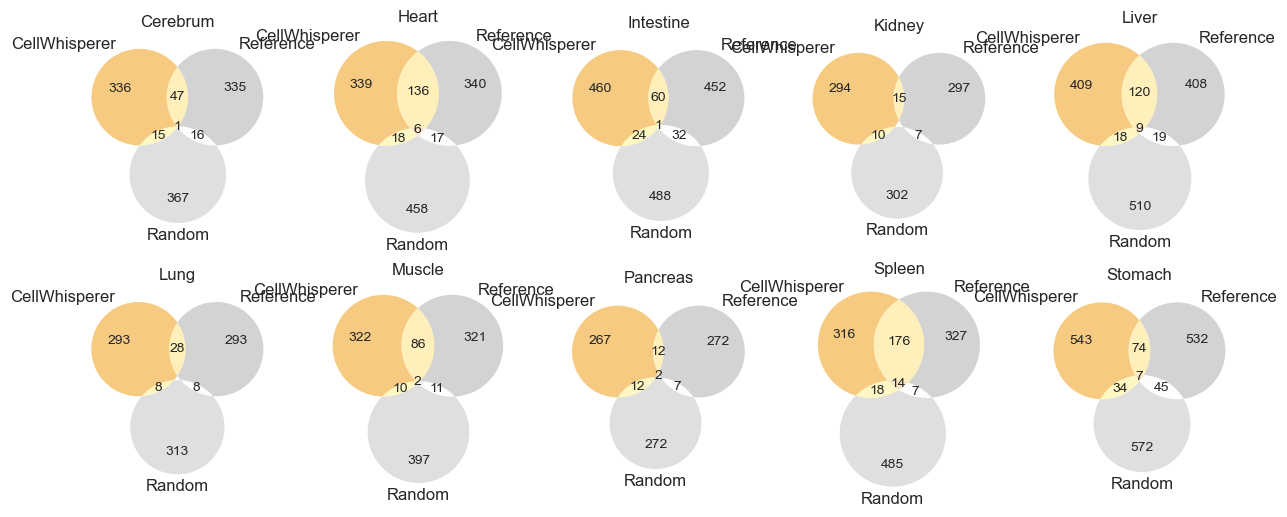

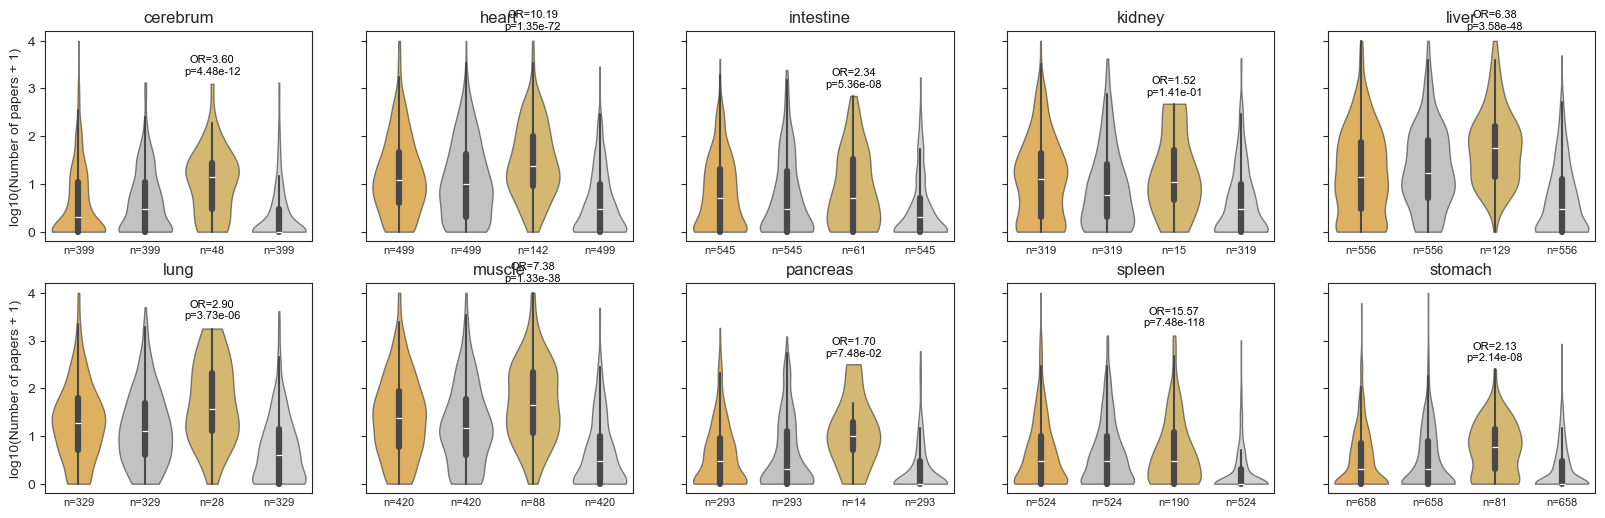

/tmp/ipykernel_1566824/2143205207.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passed_cutoff_df["Gene category"]="CellWhisperer-identified"
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promot

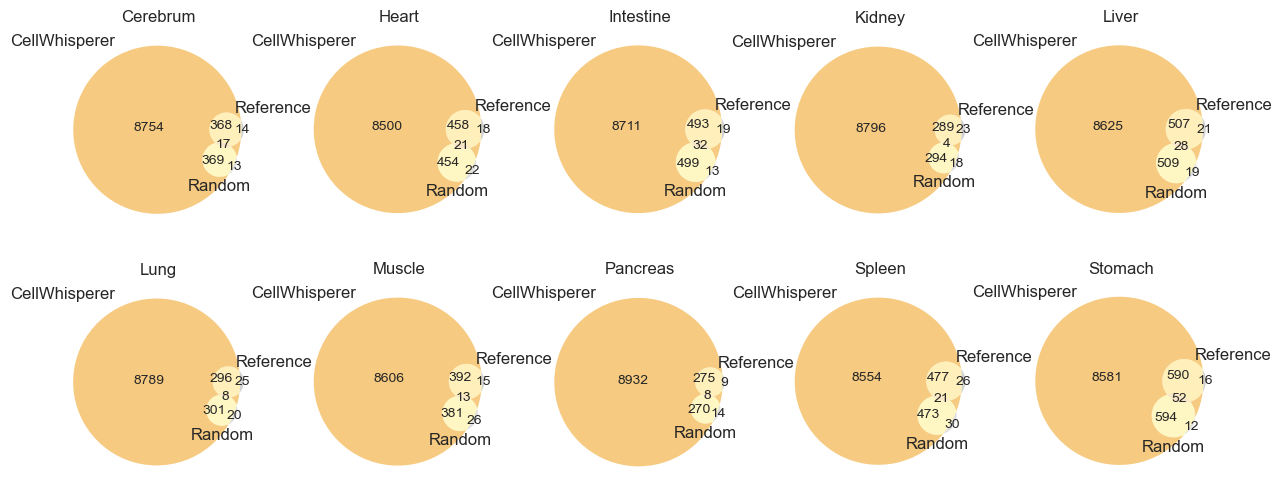

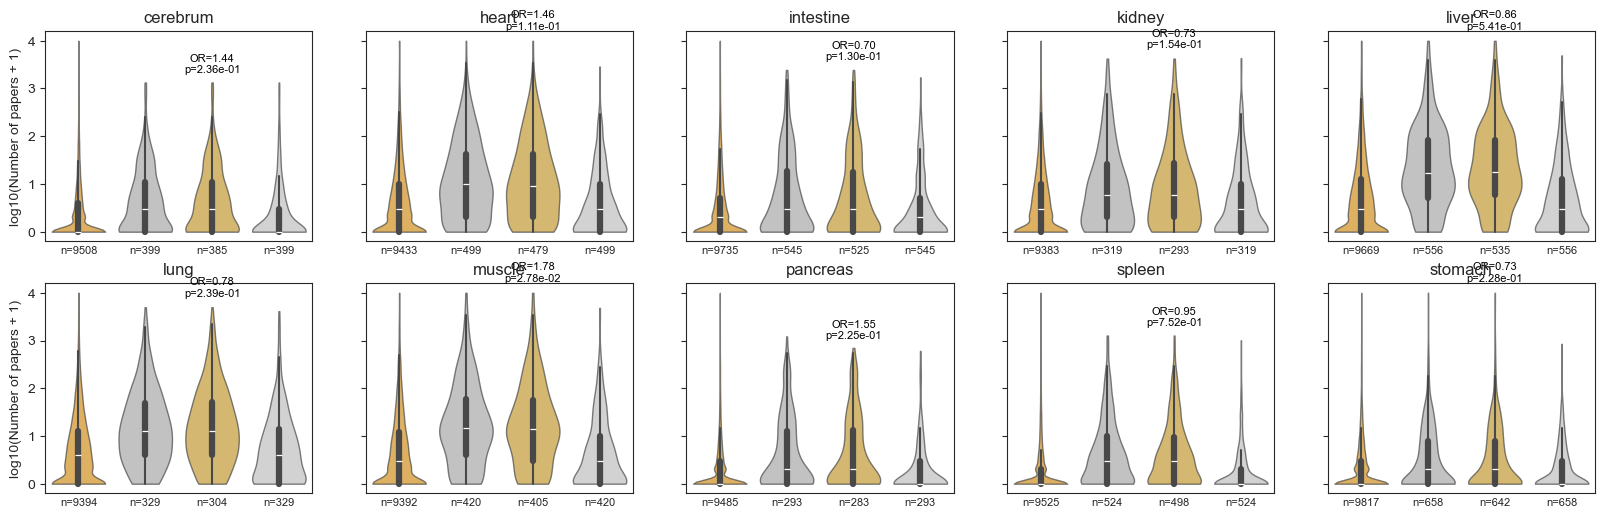

In [86]:
cutoffs_per_metric = {
    f"Correlation to CW score":("dummy","top"),
    # f"Correlation to CW score":(0.3, "larger"),
    f"logfoldchanges":("dummy","top"), # top: select the genes so
    # f"logfoldchanges":(1.5,"larger"),
    "pvals_adj":(0.05,"smaller")
}

add_random_genes=True
for metric in cutoffs_per_metric.keys():

    fig, axes = plt.subplots(2, len(ORGANS_BBI_LOWER)//2 + len(ORGANS_BBI_LOWER)%2, figsize=((4 if add_random_genes else 3) * (len(ORGANS_BBI_LOWER)//2 + len(ORGANS_BBI_LOWER)%2), 6), sharey=True)
    fig2, axes2 = plt.subplots(2, len(ORGANS_BBI_LOWER)//2 + len(ORGANS_BBI_LOWER)%2, figsize=(3 * (len(ORGANS_BBI_LOWER)//2 + len(ORGANS_BBI_LOWER)%2), 6), sharey=True)
    
    axes = axes.flatten()
    axes2 = axes2.flatten()
    
    for ax,ax2, organ in zip(axes,axes2, ORGANS_BBI_LOWER):

        metric_df=genes_df[[f"{organ}: {metric}", f"{organ}: log10(Number of papers + 1)"]]

        refgene_df = metric_df.loc[organ_extended_marker_genes_dict[organ]]
        refgene_df["Gene category"]="Reference gene"

        random_genes_df = metric_df.sample(n=len(organ_extended_marker_genes_dict[organ]), random_state=42)
        random_genes_df["Gene category"]="Random gene set"


        cutoff, larger_or_smaller = cutoffs_per_metric[metric]
        if larger_or_smaller=="larger":
            passed_cutoff_df=metric_df[metric_df[f"{organ}: {metric}"]>cutoff]
        elif larger_or_smaller=="smaller":
            passed_cutoff_df=metric_df[metric_df[f"{organ}: {metric}"]<cutoff]
        elif larger_or_smaller=="top":
            passed_cutoff_df=metric_df.sort_values(by=f"{organ}: {metric}", ascending=False).head(refgene_df.shape[0])
        else:
            raise ValueError("only larger,smaller or top allowed")
        passed_cutoff_df["Gene category"]="CellWhisperer-identified"

        common_genes = set(passed_cutoff_df.index) & set(refgene_df.index)
        common_df = passed_cutoff_df.loc[common_genes].copy()
        common_df["Gene category"]="Common"

        plot_df=pd.concat([passed_cutoff_df,refgene_df, common_df]+([random_genes_df] if add_random_genes else []))
        plt.sca(ax)
        sns.violinplot(data=plot_df, x="Gene category", y=f"{organ}: log10(Number of papers + 1)", order=["CellWhisperer-identified", "Reference gene", "Common"]+ (["Random gene set"] if add_random_genes else []), alpha=0.7, cut=0,dodge=False,
                        hue="Gene category",ax=ax, palette={"CellWhisperer-identified":"#ee9703","Reference gene":"darkgrey", "Common":"goldenrod","Random gene set":"silver"}, linewidth=1)
        # Add N numbers underneath each violin
        for i, category in enumerate(plot_df["Gene category"].unique()):
            if category in ["CellWhisperer-identified", "Reference gene", "Common"] + (["Random gene set"] if add_random_genes else []):
                subset = plot_df[plot_df["Gene category"] == category]
                n_count = len(subset)
                plt.text(i, ax.get_ylim()[0] - 0.1, f"n={n_count}", fontsize=8, ha='center', va='top')

        # remove the x ticks 
        plt.xticks([])
        plt.xlabel("")

        plt.title(f"{organ}")
        plt.ylabel(f"log10(Number of papers + 1)")
        if False:
            if passed_cutoff_df.shape[0]:
                # Test for significance: (U test)
                u_stat, pval = stats.mannwhitneyu(passed_cutoff_df[f"{organ}: log10(Number of papers + 1)"], refgene_df[f"{organ}: log10(Number of papers + 1)"], alternative="two-sided")
                plt.text(0.5, plot_df[f"{organ}: log10(Number of papers + 1)"].max()*1.01, f"p={pval:.2e}", fontsize=8, ha='center', va='bottom', color="black")
                # add line
                plt.plot([0.1,0.9], [plot_df[f"{organ}: log10(Number of papers + 1)"].max()*1.01]*2, color="black", linewidth=0.5)

            if common_df.shape[0]:
                # Now test common vs reference
                u_stat, pval = stats.mannwhitneyu(common_df[f"{organ}: log10(Number of papers + 1)"], refgene_df[f"{organ}: log10(Number of papers + 1)"], alternative="two-sided")
                plt.text(1.5, plot_df[f"{organ}: log10(Number of papers + 1)"].max()*1.01, f"p={pval:.2e}", fontsize=8, ha='center', va='bottom', color="black")
                # add line
                plt.plot([1.1,1.9], [plot_df[f"{organ}: log10(Number of papers + 1)"].max()*1.01]*2, color="black", linewidth=0.5)

        # Calculate an odds ratio, comparing the overlap sizes to expectation 
        if add_random_genes:
            common = len(common_genes)
            only_cw = len(passed_cutoff_df) - common
            only_ref = len(refgene_df) - common
            neither = BACKGROUND_GENE_SET_SIZE - (only_cw + only_ref + common)
            odds_ratio = (common * neither) / (only_cw * only_ref) if only_cw > 0 and only_ref > 0 else np.nan
            fisher_res = stats.fisher_exact([[common, only_cw], [only_ref, neither]])
            # add the odds ratio and p-value to the plot (above the violin for shared genes)
            plt.text(2, common_df[f"{organ}: log10(Number of papers + 1)"].max()*1.05, f"OR={odds_ratio:.2f}\np={fisher_res[1]:.2e}", fontsize=8, ha='center', va='bottom', color="black")

        plt.xticks(rotation=45, ha='right')

        plt.sca(ax2)
        # plot a venn diagram
        if add_random_genes:
            venn3([set(passed_cutoff_df.index), set(refgene_df.index), set(random_genes_df.index)], set_labels=(f'CellWhisperer', 'Reference','Random'),
                ax=ax2, alpha=0.5, set_colors=("#ee9703", "darkgrey","silver"))
        else:
            venn2([set(passed_cutoff_df.index), set(refgene_df.index)], set_labels=(f'CellWhisperer', 'Reference'),
                ax=ax2, alpha=0.5, set_colors=("#ee9703", "darkgrey"))
        plt.title(organ.capitalize())

    plt.sca(ax)
    plt.savefig(OUTPUT_DIR / f"literature_association_comparison_BBI_vs_{metric}.{'with_random.' if add_random_genes else ''}violinplots.pdf")
    plt.show()

    plt.sca(ax2)
    venn_dir = OUTPUT_DIR / f"venn_diagrams_{metric}_v2"
    venn_dir.mkdir(exist_ok=True)
    plot_path = venn_dir / f"venn_{metric}{'with_random.' if add_random_genes else ''}.pdf"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    # plt.show()
    plt.close()


In [74]:
plot_df

,stomach: pvals_adj,stomach: log10(Number of papers + 1),Gene category
A1BG,1.613480e-15,0.301030,CellWhisperer-identified
A1CF,7.189659e-60,0.000000,CellWhisperer-identified
A2M,1.475570e-46,1.041393,CellWhisperer-identified
A2ML1,0.000000e+00,0.000000,CellWhisperer-identified
A4GALT,0.000000e+00,0.301030,CellWhisperer-identified
...,...,...,...
ERP27,8.866334e-39,0.000000,Random gene set
ZNF57,0.000000e+00,0.000000,Random gene set
WNT4,0.000000e+00,1.079181,Random gene set
CA8,2.583994e-185,0.000000,Random gene set


In [75]:
cutoffs_per_metric = {
    f"Correlation to CW score":(0.3, "larger"),
    f"logfoldchanges":(MARKER_LOGFC_THRESHOLD,"larger"), 
}

for metric in cutoffs_per_metric.keys():

    for organ in ORGANS_BBI_LOWER:

        metric_df=genes_df[[f"{organ}: {metric}", f"{organ}: log10(Number of papers + 1)"]]

        refgene_df = metric_df.loc[organ_extended_marker_genes_dict[organ]]
        refgene_df["Gene category"]="Reference gene"

        random_genes_df = metric_df.sample(n=len(organ_extended_marker_genes_dict[organ]), random_state=42)
        random_genes_df["Gene category"]="Random gene set"

        cutoff, larger_or_smaller = cutoffs_per_metric[metric]
        if larger_or_smaller=="larger":
            passed_cutoff_df=metric_df[metric_df[f"{organ}: {metric}"]>cutoff]
        elif larger_or_smaller=="smaller":
            passed_cutoff_df=metric_df[metric_df[f"{organ}: {metric}"]<cutoff]
        elif larger_or_smaller=="top":
            passed_cutoff_df=metric_df.sort_values(by=f"{organ}: {metric}", ascending=False).head(refgene_df.shape[0])
        else:
            raise ValueError("only larger,smaller or top allowed")
        passed_cutoff_df["Gene category"]="CellWhisperer-identified"


    # 
        enrichment_dir = OUTPUT_DIR / f"enrichment_plots_{metric}"
        enrichment_dir.mkdir(exist_ok=True)
        enr_dict = run_gsea_enrichment(list(passed_cutoff_df.index), ENRICHMENT_LIBRARIES, organism='human')

        # Combine results from different libraries if needed
        valid_dfs = [df for df in enr_dict.values() if not df.empty]
        if valid_dfs:
            combined_enr_df = pd.concat(valid_dfs, ignore_index=True)
            combined_enr_df = combined_enr_df.sort_values("Adjusted P-value")

        gp.dotplot(combined_enr_df,
            column="Adjusted P-value",
            title=f"{organ.capitalize()} - Top Enriched Terms ({metric})",
            ofname=str(enrichment_dir / f"{organ}_enrichment_dotplot_{metric}.{larger_or_smaller}_{cutoff}.pdf"), # Ensure path is string
            top_term=10, # Show top 10 terms
            figsize=(6, 5),
            marker='o', show_ring=True
        )

/tmp/ipykernel_1566824/1829672272.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passed_cutoff_df["Gene category"]="CellWhisperer-identified"


/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/tmp/ipykernel_1566824/1829672272.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passed_cutoff_df["Gene category"]="CellWhisperer-identified"
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promot

/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/tmp/ipykernel_1566824/1829672272.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passed_cutoff_df["Gene category"]="CellWhisperer-identified"
/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promot

In [76]:
organ

'stomach'

In [77]:
combined_enr_df

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
4601,KEGG_2021_Human,Ferroptosis,14/41,4.234079e-07,0.000124,0,0,6.868427,1.007937e+02,PRNP;TFRC;NCOA4;SLC40A1;SLC3A2;ACSL4;SLC7A11;S...
0,GO_Biological_Process_2023,Keratinocyte Differentiation (GO:0030216),15/42,8.242879e-08,0.000299,0,0,7.364286,1.201213e+02,CERS3;DSP;SPRR3;CLIC4;SPRR2G;ANXA1;OPN3;TGM1;B...
1,GO_Biological_Process_2023,Regulation Of Inflammatory Response (GO:0050727),40/240,3.360960e-07,0.000609,0,0,2.674182,3.986100e+01,CEBPA;SEMA7A;SERPINE1;XIAP;TNFAIP3;GATA3;AHR;N...
3623,GO_Molecular_Function_2023,Amino Acid Transmembrane Transporter Activity ...,16/56,1.004827e-06,0.000609,0,0,5.302359,7.322926e+01,SLC38A1;SLC6A19;SLC36A2;SLC43A2;SLC1A3;SLC3A2;...
3624,GO_Molecular_Function_2023,Phosphatidylcholine-Sterol O-acyltransferase A...,5/5,1.760924e-06,0.000609,0,0,92925.000000,1.231226e+06,APOC1;APOA2;APOA4;APOE;APOA5
...,...,...,...,...,...,...,...,...,...,...
4844,KEGG_2021_Human,beta-Alanine metabolism,1/30,8.895254e-01,0.999995,0,0,0.452519,5.297516e-02,SMOX
4855,KEGG_2021_Human,Phosphatidylinositol signaling system,4/97,9.190712e-01,0.999995,0,0,0.563682,4.757006e-02,CALML5;IMPA2;PTEN;PIK3C2A
4854,KEGG_2021_Human,Circadian entrainment,4/97,9.190712e-01,0.999995,0,0,0.563682,4.757006e-02,RPS6KA5;GNGT2;CALML5;GNG12
4853,KEGG_2021_Human,Leishmaniasis,3/77,9.166089e-01,0.999995,0,0,0.531477,4.627806e-02,NFKBIA;NOS2;TNF


In [80]:
suppl_table["CellWhisperer-associated and novel: Organs"]

A1BG      []
A1CF      []
A2M       []
A2ML1     []
A4GALT    []
          ..
ZSWIM8    []
ZWINT     []
ZYG11B    []
ZYX       []
ZZEF1     []
Name: CellWhisperer-associated and novel: Organs, Length: 10000, dtype: object

In [83]:
# Cleaner table:
# only columns: f"{organ}: Number of PMIDs", f"{organ}: logfoldchanges", f"{organ}: logfoldchanges: category", CS8_mean_expression_zscore, CS8_Q97_expression_zscore
# new column: Hit (if for any organ the number of PMIDs is 0 and the corresponding logfoldchange is > 1.5)

suppl_table = genes_df.copy()
suppl_table["CellWhisperer-associated and novel"]=False
suppl_table["CellWhisperer-associated and novel: Organs"]= [[] for _ in range(len(suppl_table))]

keep_cols = ["CellWhisperer-associated and novel","CellWhisperer-associated and novel: Organs"]
for organ in ORGANS_BBI_LOWER:
    selector=(suppl_table[f"{organ}: Number of PMIDs"]==0) & (suppl_table[f"{organ}: logfoldchanges"]>MARKER_LOGFC_THRESHOLD)
    suppl_table.loc[selector, "CellWhisperer-associated and novel"]=True
    # Iterate through selected indices and append to each individual list
    for idx in suppl_table[selector].index:
        suppl_table.at[idx, "CellWhisperer-associated and novel: Organs"].append(organ)
    keep_cols+=[f"{organ}: Number of PMIDs", f"{organ}: logfoldchanges"]
keep_cols += ["CS8_mean_expression_zscore", "CS8_Q97_expression_zscore"]
suppl_table=suppl_table[keep_cols]
# rename all instances of "logfoldchanges" to "expression enrichment (log2FC)"
for col in suppl_table.columns:
    if "logfoldchanges" in col:
        suppl_table.rename(columns={col: col.replace("logfoldchanges", "expression enrichment (log2FC)")}, inplace=True)
# rename "CS8_mean_expression_zscore" to "Mean expression at CS8 (z-score)"
suppl_table.rename(columns={"CS8_mean_expression_zscore": "Mean expression at CS8 (z-score)"}, inplace=True)
# rename "CS8_Q97_expression_zscore" to "Q97 expression at CS8 (z-score)"
suppl_table.rename(columns={"CS8_Q97_expression_zscore": "Q97 expression at CS8 (z-score)"}, inplace=True)
# rename all instances of "Number of PMIDs" to "Number of papers"
for col in suppl_table.columns:
    if "Number of PMIDs" in col:
        suppl_table.rename(columns={col: col.replace("Number of PMIDs", "Number of papers")}, inplace=True)
suppl_table.to_excel(OUTPUT_DIR / "Suppl_table.xlsx")

In [ ]:
    
# Define genes to be tested
strongDEgenes_per_organ={organ:lit_assoc_and_DE_cross_organs_df[(lit_assoc_and_DE_cross_organs_df["Organ"]==organ) & (lit_assoc_and_DE_cross_organs_df["logfoldchanges"]>CUTOFF_DISEASE_ASSOCIATION)]["names"].values.tolist() for organ in lit_assoc_and_DE_cross_organs_df.Organ.unique()}

# Run overlap analysis
enrichments, overlaps = run_disease_enrichment(strongDEgenes_per_organ, developmental_diseases_dict, BACKGROUND_GENE_SET_SIZE)

# Save Pvals per organ per disease
enrichments.to_csv(OUTPUT_DIR / "disease_enrichments.csv")


# Add the overlap info to the DF (annotate which gene was found in which disease)
overlaps_merged_df= pd.concat([x.reset_index() for x in overlaps.values()], ignore_index=True)
lit_assoc_and_DE_cross_organs_df[f"Associated with any disease"]=False
for disease in overlaps_merged_df["Disease"].unique():
    lit_assoc_and_DE_cross_organs_df[f"Associated with {disease}"]=False
    associated_genes=overlaps_merged_df[overlaps_merged_df["Disease"]==disease]["Gene"].values.tolist()
    lit_assoc_and_DE_cross_organs_df.loc[lit_assoc_and_DE_cross_organs_df["names"].isin(associated_genes), f"Associated with {disease}"]=True
    lit_assoc_and_DE_cross_organs_df.loc[lit_assoc_and_DE_cross_organs_df["names"].isin(associated_genes), "Associated with any disease"]=True

# Save the gene info df
lit_assoc_and_DE_cross_organs_df.to_excel(OUTPUT_DIR / "genes_info_DE_literature_diseases.xlsx", index=False)

interesting_hits = lit_assoc_and_DE_cross_organs_df.loc[(lit_assoc_and_DE_cross_organs_df["Associated with any disease"]) & (lit_assoc_and_DE_cross_organs_df["Num_Papers"]==0)]
interesting_hits.to_excel(OUTPUT_DIR / "interesting_hits.xlsx", index=False)



In [ ]:
pk_path="output/literature_search_results_M1.pickle" # Currently uses logFC 1 as cutoff
with open(pk_path, 'rb') as handle:
    literature_m1 = pk.load(handle)

In [ ]:
# Run searches for Method 1 and Method 2 if markers exist
# literature_m1 = perform_literature_search(cw_markers_m1, organ_extended_marker_genes_dict, ORGANS_BBI_LOWER, OUTPUT_DIR, "M1")
#literature_m2 = perform_literature_search(cw_markers_m2, organ_extended_marker_genes_dict, ORGANS_BBI_LOWER, OUTPUT_DIR, "M2")

In [ ]:
literature_m2 = perform_literature_search(cw_markers_m2, organ_extended_marker_genes_dict, ORGANS_BBI_LOWER, OUTPUT_DIR, "M2")

In [ ]:
# Run literature marker analysis for ALL genes (test):
# literature_all = perform_literature_search({"heart":adata.var.index.to_list()}, {"heart":set()}, ["heart"], OUTPUT_DIR, "heart_all")

# load pickle:
pk_path="output/literature_search_results_heart_all.pickle"
with open(pk_path, 'rb') as handle:
    literature_all = pk.load(handle)

In [ ]:
lit_df = plot_literature_comparison(literature_all, OUTPUT_DIR)

In [ ]:
lit_df_m1_logFC1 = plot_literature_comparison(literature_m1, OUTPUT_DIR)

In [ ]:
lit_df_m2_logFC1 = plot_literature_comparison(literature_m2, OUTPUT_DIR)


Note that the results are different because 0s were not dropped, but instead log1p is visualized for the per-organ plots

In [ ]:
lit_df_m1_logFC1

In [ ]:
lit_df

In [ ]:
merged_dfs_per_organ_logFC1=plot_and_get_enrichment_vs_literature(cw_dfs_m1, lit_df_m1_logFC1, outdir=OUTPUT_DIR, enrichment_strength_col="logfoldchanges", lowess=True,
                                                                  bins_edges=[1,1.5,2,2.5,3], start_box=(1.5, -0.5), width_box=2)

In [ ]:
# merge the df's 
lit_assoc_and_DE_cross_organs_df = pd.concat(merged_dfs_per_organ_logFC1.values(), ignore_index=True)

In [ ]:
df_across_organs

In [ ]:
merged_dfs_per_organ=plot_and_get_enrichment_vs_literature(cw_dfs_m1, lit_df, outdir=OUTPUT_DIR, enrichment_strength_col="logfoldchanges",  lowess=True)

In [ ]:
merged_dfs_per_organ["heart"]

In [ ]:
literature_results=lit_df
enrichment_results = cw_dfs_m1
plot_enrichment_vs_literature(enrichment_results, literature_results, enrichment_strength_col="logfoldchanges", outdir=OUTPUT_DIR)

In [ ]:
# plot_enrichment_vs_literature(enrichment_results, literature_results, enrichment_strength_col="scores", outdir=OUTPUT_DIR, color_cutoff_col="logfoldchanges")

## 11. Disease Gene Set Enrichment

In [ ]:
print("\n--- Analyzing Enrichment of Disease Gene Sets ---")

In [ ]:
# Unzip the file first if neccesary
if not DISEASE_DATA_DIR.exists():
    with zipfile.ZipFile(DISEASE_ZIP, 'r') as zip_ref:
        zip_ref.extractall(DISEASE_ZIP.parent)

In [ ]:
DISEASE_DATA_DIR

In [ ]:
# --- Load Disease Gene Sets ---
developmental_diseases_dict = {}
disease_files = {
    "bone_development": "bone_development_disease.tab",
    "congenital_heart": "congenital_heart_disease.tab",
    "congenital_myopathy": "congenital_myopathy.tab",
    "fetal_akinesia": "fetal_akinesia.tab",
    "fetal_diseases": "fetal_diseases.tab",
    "newborn_diseases": "infant,newborn_diseases.tab",
    "language_development": "language_development.tab",
    "neurodevelopmental": "neurodevelopmental_disorders.tab",
}

In [ ]:
available_genes = set(adata.var_names)

In [ ]:
for disease_key, filename in disease_files.items():
    filepath = DISEASE_DATA_DIR / filename
    try:
        # POTENTIAL ISSUE: Encoding might vary. Added error handling.
        df = pd.read_csv(filepath, sep="\t", encoding='utf-8', on_bad_lines='skip') # Try utf-8 first
    except UnicodeDecodeError:
        try:
             df = pd.read_csv(filepath, sep="\t", encoding='latin-1', on_bad_lines='skip') # Fallback encoding
        except Exception as e:
             warnings.warn(f"Could not read disease file {filepath}: {e}")
             continue

    if 'Symbol' in df.columns:
         # Convert symbols to string, handle potential NaN, filter by available genes
         disease_genes = set(df['Symbol'].astype(str).dropna()) & available_genes
         developmental_diseases_dict[disease_key] = disease_genes
         print(f"Loaded {len(disease_genes)} genes for {disease_key} (available in data).")
    else:
        warnings.warn(f"'Symbol' column not found in {filepath}. Cannot load genes for {disease_key}.")

In [ ]:
# Load pediatric cancer genes
try:
    ped_cancer_df = pd.read_csv(PEDIATRIC_CANCER_GENES_PATH, sep="\t")
    if 'Name' in ped_cancer_df.columns:
        ped_cancer_genes = set(ped_cancer_df['Name'].astype(str).dropna()) & available_genes
        developmental_diseases_dict['pediatric_cancer'] = ped_cancer_genes
        print(f"Loaded {len(ped_cancer_genes)} pediatric cancer genes (available in data).")
    else:
        warnings.warn(f"'Name' column not found in {PEDIATRIC_CANCER_GENES_PATH}.")
except FileNotFoundError:
    warnings.warn(f"Pediatric cancer gene file not found at {PEDIATRIC_CANCER_GENES_PATH}.")
except Exception as e:
    warnings.warn(f"Could not read pediatric cancer gene file: {e}")

In [ ]:
# Define genes to be tested
strongDEgenes_per_organ={organ:lit_assoc_and_DE_cross_organs_df[(lit_assoc_and_DE_cross_organs_df["Organ"]==organ) & (lit_assoc_and_DE_cross_organs_df["logfoldchanges"]>CUTOFF_DISEASE_ASSOCIATION)]["names"].values.tolist() for organ in lit_assoc_and_DE_cross_organs_df.Organ.unique()}

# Run overlap analysis
enrichments, overlaps = run_disease_enrichment(strongDEgenes_per_organ, developmental_diseases_dict, BACKGROUND_GENE_SET_SIZE)

# Save Pvals per organ per disease
enrichments.to_csv(OUTPUT_DIR / "disease_enrichments.csv")


# Add the overlap info to the DF (annotate which gene was found in which disease)
overlaps_merged_df= pd.concat([x.reset_index() for x in overlaps.values()], ignore_index=True)
lit_assoc_and_DE_cross_organs_df[f"Associated with any disease"]=False
for disease in overlaps_merged_df["Disease"].unique():
    lit_assoc_and_DE_cross_organs_df[f"Associated with {disease}"]=False
    associated_genes=overlaps_merged_df[overlaps_merged_df["Disease"]==disease]["Gene"].values.tolist()
    lit_assoc_and_DE_cross_organs_df.loc[lit_assoc_and_DE_cross_organs_df["names"].isin(associated_genes), f"Associated with {disease}"]=True
    lit_assoc_and_DE_cross_organs_df.loc[lit_assoc_and_DE_cross_organs_df["names"].isin(associated_genes), "Associated with any disease"]=True

# Save the gene info df
lit_assoc_and_DE_cross_organs_df.to_excel(OUTPUT_DIR / "genes_info_DE_literature_diseases.xlsx", index=False)

interesting_hits = lit_assoc_and_DE_cross_organs_df.loc[(lit_assoc_and_DE_cross_organs_df["Associated with any disease"]) & (lit_assoc_and_DE_cross_organs_df["Num_Papers"]==0)]
interesting_hits.to_excel(OUTPUT_DIR / "interesting_hits.xlsx", index=False)



In [ ]:
[key  for key, values  in cw_markers_m1.items() if "LCN15" in values]

In [ ]:
canidates=merged_dfs_per_organ["heart"][(merged_dfs_per_organ["heart"]["Num_Papers"]==0) & (merged_dfs_per_organ["heart"]["logfoldchanges"]>2)]
hits_with_disease_assoc=list(set([x for x in overlaps_heart["heart"].index if x in canidates["names"].values.tolist()]))

display(overlaps_heart["heart"].loc[hits_with_disease_assoc])
display(merged_dfs_per_organ["heart"][merged_dfs_per_organ["heart"]["names"].isin(hits_with_disease_assoc)])


In [ ]:
type(developmental_diseases_dict["congenital_heart"])

In [ ]:
# Run for Reference, CW M1, CW M2
print("\nRunning disease enrichment tests...")
enrichment_ref = run_disease_enrichment(organ_extended_marker_genes_dict, developmental_diseases_dict, BACKGROUND_GENE_SET_SIZE)
enrichment_cw_m1 = run_disease_enrichment(cw_markers_m1, developmental_diseases_dict, BACKGROUND_GENE_SET_SIZE)
enrichment_cw_m2 = run_disease_enrichment(cw_markers_m2, developmental_diseases_dict, BACKGROUND_GENE_SET_SIZE)

In [ ]:
# Plot for each method
plot_significant_enrichment(enrichment_ref, "Disease Enrichment in Reference Markers", "disease_enrichment_ref.pdf", OUTPUT_DIR)
plot_significant_enrichment(enrichment_cw_m1, "Disease Enrichment in CW M1 Markers", "disease_enrichment_cw_m1.pdf", OUTPUT_DIR)
plot_significant_enrichment(enrichment_cw_m2, "Disease Enrichment in CW M2 Markers", "disease_enrichment_cw_m2.pdf", OUTPUT_DIR)

## 12. Dominant Organ Classification & Composition

In [ ]:
print("\n--- Analyzing Dominant Organ Classification ---")

In [ ]:
# --- Classify using Reference (BBI) Markers ---
if organ_extended_marker_genes_dict:
    adata.obs["dominant_organ_ref"] = classify_dominant_organ(adata, organ_extended_marker_genes_dict, "Reference_BBI")
    #plot_umap(adata, "dominant_organ_ref", OUTPUT_DIR, "dominant_organ", palette=ORGAN_COLORS, title="Dominant Organ (Reference Markers)")
else:
     warnings.warn("Skipping reference dominant organ classification: BBI markers missing.")
     adata.obs["dominant_organ_ref"] = "None"

In [ ]:
# --- Classify using CW Markers (Method 1) ---
if cw_markers_m1:
     adata.obs["dominant_organ_cw_m1"] = classify_dominant_organ(adata, cw_markers_m1, "CW_M1")
     plot_umap(adata, "dominant_organ_cw_m1", OUTPUT_DIR, "dominant_organ", palette=ORGAN_COLORS, title="Dominant Organ (CW Method 1 Markers)")
else:
     warnings.warn("Skipping CW M1 dominant organ classification: CW M1 markers missing.")
     adata.obs["dominant_organ_cw_m1"] = "None"

In [ ]:
# --- Classify using CW Markers (Method 2) ---
if cw_markers_m2:
     adata.obs["dominant_organ_cw_m2"] = classify_dominant_organ(adata, cw_markers_m2, "CW_M2")
     plot_umap(adata, "dominant_organ_cw_m2", OUTPUT_DIR, "dominant_organ", palette=ORGAN_COLORS, title="Dominant Organ (CW Method 2 Markers)")
else:
     warnings.warn("Skipping CW M2 dominant organ classification: CW M2 markers missing.")
     adata.obs["dominant_organ_cw_m2"] = "None"

In [ ]:
# Compare CW M1 vs Reference
plot_sankey_comparison(adata, "dominant_organ_cw_m1", "dominant_organ_ref",
                       "Dominant Organ: CW Method 1 vs Reference Markers",
                       "sankey_cw_m1_vs_ref.pdf", OUTPUT_DIR)
# Compare CW M2 vs Reference
plot_sankey_comparison(adata, "dominant_organ_cw_m2", "dominant_organ_ref",
                       "Dominant Organ: CW Method 2 vs Reference Markers",
                       "sankey_cw_m2_vs_ref.pdf", OUTPUT_DIR)

In [ ]:
# Plot for Reference markers
plot_bipartite_composition(adata, "dominant_organ_ref", "anno_og",
                           "Composition: Dominant Organ (Reference) vs Original Annotation",
                           "bipartite_ref_vs_anno.pdf", OUTPUT_DIR)
# Plot for CW M1 markers
plot_bipartite_composition(adata, "dominant_organ_cw_m1", "anno_og",
                           "Composition: Dominant Organ (CW M1) vs Original Annotation",
                           "bipartite_cw_m1_vs_anno.pdf", OUTPUT_DIR)
# Plot for CW M2 markers
plot_bipartite_composition(adata, "dominant_organ_cw_m2", "anno_og",
                           "Composition: Dominant Organ (CW M2) vs Original Annotation",
                           "bipartite_cw_m2_vs_anno.pdf", OUTPUT_DIR)

## 13. Final AnnData Saving (Optional)

Save the AnnData object with all the new annotations
POTENTIAL ISSUE: This can create very large files if many scores/annotations were added.
Consider saving only essential columns or a subset of the data if space is a concern.

In [ ]:
final_adata_path = OUTPUT_DIR / "annotated_cellxgene.h5ad"
try:
    adata.write_h5ad(final_adata_path, compression="gzip")
    print(f"\nSaved final annotated AnnData object to: {final_adata_path}")
except Exception as e:
    warnings.warn(f"Could not save final AnnData object: {e}")

In [ ]:
print(f"\nAnalysis finished: {datetime.datetime.now()}")